In [46]:
import numpy as np
import pandas as pd
from scipy import stats

df = pd.read_csv('/Users/vrundgurjar/Downloads/chipotle_data.csv')
df = df[df['year'] < 2025].sort_values('year').reset_index(drop=True)
df['revenue_growth']    = df['revenue'].pct_change()
df['cogs_growth']       = df['cogs'].pct_change()
df['asset_growth']      = df['total_assets'].pct_change()
df['prev_op_margin']    = df['operating_margin'].shift(1)
df['prev_gross_margin'] = df['gross_margin'].shift(1)
df['prev_net_margin']   = df['net_profit_margin'].shift(1)
df = df.dropna().reset_index(drop=True)
print(f"✓ {len(df)} observations loaded")

✓ 18 observations loaded


In [47]:
recent = df.tail(4)
print(f"Base rev growth: {recent['revenue_growth'].mean():.4f}")
print(f"Rev growth std:  {recent['revenue_growth'].std():.4f}")
print(f"Base op margin:  {recent['operating_margin'].mean():.4f}")
print(f"Op margin std:   {df['operating_margin'].std():.4f}")

Base rev growth: 0.1736
Rev growth std:  0.0583
Base op margin:  14.2075
Op margin std:   5.1321


In [48]:
# ══════════════════════════════════════════════════
# CONSTANTS & ML-DERIVED PARAMETERS
# These come directly from our OLS regression output
# Only statistically significant coefficients used
# ══════════════════════════════════════════════════

N_SIMS  = 10_000
N_YEARS = 5
YEARS   = [2025, 2026, 2027, 2028, 2029]

ML_PARAMS = {
    'base_rev_growth':    0.1736,   # 4yr avg revenue growth
    'rev_growth_std':     0.0583,   # 4yr std dev — our uncertainty band
    'base_op_margin':     0.142075, # 4yr avg operating margin (as decimal)
    'op_margin_std':      0.051321, # historical volatility (as decimal)
    'op_to_net_coef':     0.5759,   # Model C β₁ — only significant term
    'initial_revenue':    11313.853,# 2024 actual ($M)
    'initial_op_income':  1916.332, # 2024 actual ($M)
    'initial_fcf':        1511.473, # 2024 actual ($M)
}

print("✓ ML Parameters loaded")
print(f"  Base revenue growth:  {ML_PARAMS['base_rev_growth']*100:.2f}%")
print(f"  Growth uncertainty:  ±{ML_PARAMS['rev_growth_std']*100:.2f}%")
print(f"  Base operating margin: {ML_PARAMS['base_op_margin']*100:.2f}%")
print(f"  Op→Net passthrough:    {ML_PARAMS['op_to_net_coef']:.4f}")

✓ ML Parameters loaded
  Base revenue growth:  17.36%
  Growth uncertainty:  ±5.83%
  Base operating margin: 14.21%
  Op→Net passthrough:    0.5759


In [49]:
# ══════════════════════════════════════════════════
# SOLUTIONS CONFIG
# Each boost is a triangular distribution (min, likely, max)
# Grounded in cited research — not assumed
# ══════════════════════════════════════════════════

SOLUTIONS = {
    'subscription': {
        'name':         'Chips & Drinks Subscription',
        # Taco Bell 3x frequency, 5-15% penetration assumed
        # Panera Unlimited Sip Club drove 2.5x frequency jump
        'rev_boost':    (0.015, 0.030, 0.050),
        # Chips/drinks low incremental COGS → margin positive
        'margin_boost': (0.005, 0.010, 0.018),
        'weight':        0.35,
        'citation':     'Taco Bell Pass: 3x visit frequency; Panera: 2.5x frequency jump',
    },
    'float': {
        'name':         'Stored-Value Float Strategy',
        # Q4 2025 breakage $27M, up $19.1M YoY
        # Industry breakage 6-10% of float — near 100% margin
        'rev_boost':    (0.005, 0.012, 0.020),
        # Near-zero COGS revenue line — outsized margin impact
        'margin_boost': (0.008, 0.015, 0.025),
        'weight':        0.25,
        'citation':     'CMG Q4 2025: $27M breakage revenue, +$19.1M YoY; industry rate 6-10%',
    },
    'international': {
        'name':         'International Expansion',
        # Canada 81 locations May 2026, sales nearly tripled in 5 yrs, AUVs = U.S. parity
        # Kuwait AUV exceeded U.S. average in yr 1; CEO target: intl = 1-2x N.Am. business
        # 10-15 new partner-operated openings guided for 2026; Mexico debut via Alsea
        'rev_boost':    (0.008, 0.020, 0.035),
        # Partner/licensed model = asset-light, minimal incremental COGS → margin accretive
        # Long-term algo: "approaching 30% margins" — CEO Q4 2025 call
        'margin_boost': (0.004, 0.010, 0.018),
        'weight':        0.40,
        'citation':     'Canada AUVs at U.S. parity, sales 3x in 5yr; Kuwait yr-1 AUV above U.S. avg; CEO: intl = 1-2x N.Am. long-term',
    },
}

print("✓ Solutions loaded")
for k, v in SOLUTIONS.items():
    print(f"\n  {v['name']}")
    print(f"    Rev boost:    {v['rev_boost'][0]*100:.1f}% – {v['rev_boost'][2]*100:.1f}% (likely {v['rev_boost'][1]*100:.1f}%)")
    print(f"    Margin boost: {v['margin_boost'][0]*100:.1f}% – {v['margin_boost'][2]*100:.1f}% (likely {v['margin_boost'][1]*100:.1f}%)")
    print(f"    Citation:     {v['citation']}")

✓ Solutions loaded

  Chips & Drinks Subscription
    Rev boost:    1.5% – 5.0% (likely 3.0%)
    Margin boost: 0.5% – 1.8% (likely 1.0%)
    Citation:     Taco Bell Pass: 3x visit frequency; Panera: 2.5x frequency jump

  Stored-Value Float Strategy
    Rev boost:    0.5% – 2.0% (likely 1.2%)
    Margin boost: 0.8% – 2.5% (likely 1.5%)
    Citation:     CMG Q4 2025: $27M breakage revenue, +$19.1M YoY; industry rate 6-10%

  International Expansion
    Rev boost:    0.8% – 3.5% (likely 2.0%)
    Margin boost: 0.4% – 1.8% (likely 1.0%)
    Citation:     Canada AUVs at U.S. parity, sales 3x in 5yr; Kuwait yr-1 AUV above U.S. avg; CEO: intl = 1-2x N.Am. long-term


In [50]:
# ══════════════════════════════════════════════════
# SCENARIO CONFIG
# Macro conditions modeled as multipliers on strategy
# Bear = strategy underperforms + macro headwinds
# Base = strategy performs as cited research suggests  
# Bull = strategy outperforms + favorable macro
# ══════════════════════════════════════════════════

SCENARIOS = {
    'bear': {
        'macro_drag':    -0.025,  # 2.5% headwind on base growth
        'strategy_mult':  0.40,   # strategy only 40% as effective
        'label':         'Bear',
        'color':         '#D44000'
    },
    'base': {
        'macro_drag':     0.000,
        'strategy_mult':  1.00,
        'label':         'Base',
        'color':         '#A81612'
    },
    'bull': {
        'macro_drag':     0.010,
        'strategy_mult':  1.60,
        'label':         'Bull',
        'color':         '#2D5016'
    },
}

print("✓ Scenarios loaded: Bear / Base / Bull")

✓ Scenarios loaded: Bear / Base / Bull


## Stochastic Process Upgrade: GBM & Ornstein-Uhlenbeck

### Why Upgrade from Simple Normal Draws?
The original model drew revenue growth and operating margin independently each year from a normal distribution — stationary, memoryless, and unconstrained.  
Real financial processes have **temporal structure**: revenue compounds multiplicatively (last year's level sets the base), and margins exhibit **mean reversion** (they drift back toward a long-run structural average).  
Two classical stochastic processes capture exactly these dynamics.

---

### Geometric Brownian Motion (GBM) — Revenue

**The SDE:** `dS = μS dt + σS dW`

In plain English: revenue changes each period by a deterministic drift (μ = expected growth rate) plus a random shock (σ dW) that *scales with the current revenue level*. Two key advantages for modelling revenue:

1. **Non-negativity guaranteed** — S can never go negative (you cannot have negative revenue).
2. **Multiplicative growth** — a 10 % shock on \$15 B matters far more than on \$11 B, which is how real revenue shocks work.

**Discretized via Euler-Maruyama (annual step, dt = 1):**
> S_{t+1} = S_t × (1 + μ·dt + σ·√dt·Z),  Z ~ N(0,1)

**Parameters estimated from our existing regression output:**
- **μ** (drift) = `ML_PARAMS['base_rev_growth']` = 17.36 % — 4-year average revenue growth, adjusted by scenario macro drag.
- **σ** (volatility) = `ML_PARAMS['rev_growth_std']` = 5.83 % — 4-year standard deviation of revenue growth from historical data.

---

### Ornstein-Uhlenbeck (OU) Process — Operating Margin

**The SDE:** `dX = θ(μ − X) dt + σ dW`

In plain English: the operating margin is pulled toward its long-run average (μ) at speed θ, with Gaussian noise σ dW on top. This is exactly the behaviour we expect from a restaurant chain — extreme margins in either direction invite competitive pressure and cost responses that pull margin back toward a structural equilibrium.

**Discretized via Euler-Maruyama (annual step, dt = 1):**
> X_{t+1} = X_t + θ·(μ − X_t)·dt + σ·√dt·Z,  Z ~ N(0,1)

**Why the OU is consistent with our own OLS regression:**  
Model A found `BETA2_A = 0.6927` as the lagged-margin coefficient — this is a discrete-time AR(1) persistence parameter.  
In continuous time, an AR(1) with annual coefficient β corresponds to a OU process with mean-reversion speed:

> θ = −ln(β) = −ln(0.6927) ≈ **0.366 per year**

(Derivation: the exact discrete solution of the OU SDE over Δt = 1 year gives X_{t+1} = μ + e^{−θ}(X_t − μ) + noise, so e^{−θ} = β → θ = −ln β.)

This means margins close roughly **30.7 %** of the gap to the long-run mean each year (1 − e^{−0.366} ≈ 0.307), perfectly consistent with the 69 % persistence our regression measured.

**Parameters:**
- **μ** (long-run mean) = `ML_PARAMS['base_op_margin']` = 14.21 % — 4-year average operating margin.
- **σ** (diffusion vol) = `ML_PARAMS['op_margin_std']` = 5.13 % — historical margin standard deviation.
- **θ** (reversion speed) = −ln(0.6927) ≈ 0.366 — derived directly from the OLS AR(1) coefficient `BETA2_A`.

---

Strategy solution boosts (subscription, float, international) are applied as additive increments on top of the OU state each year and do not feed back into the OU diffusion — this keeps the base stochastic process clean while preserving the strategy upside. The GBM base growth and OU margin paths are fully vectorised across all 10,000 simulations, eliminating the slow per-simulation Python loop.


In [ ]:
# ══════════════════════════════════════════════════
# SIMULATION ENGINE — GBM Revenue + OU Operating Margin
# Revenue: Geometric Brownian Motion  dS = μS dt + σS dW
# Margin:  Ornstein-Uhlenbeck         dX = θ(μ-X) dt + σ dW
# Both fully vectorised across N_SIMS; outer loop is N_YEARS only.
# ══════════════════════════════════════════════════

import numpy as np

def compute_boosts(scenario_mult):
    rev_min  = sum(s['rev_boost'][0]    for s in SOLUTIONS.values()) * scenario_mult
    rev_mode = sum(s['rev_boost'][1]    for s in SOLUTIONS.values()) * scenario_mult
    rev_max  = sum(s['rev_boost'][2]    for s in SOLUTIONS.values()) * scenario_mult
    mar_min  = sum(s['margin_boost'][0] for s in SOLUTIONS.values()) * scenario_mult
    mar_mode = sum(s['margin_boost'][1] for s in SOLUTIONS.values()) * scenario_mult
    mar_max  = sum(s['margin_boost'][2] for s in SOLUTIONS.values()) * scenario_mult
    return (rev_min, rev_mode, rev_max, mar_min, mar_mode, mar_max)

# OLS Model A coefficients — retained for reference; BETA2_A drives OU theta
INTERCEPT_A = -1.3892
BETA1_A     = 31.8584
BETA2_A     =  0.6927

# OU mean-reversion speed derived from discrete AR(1) coefficient:
# exact OU solution over dt=1 yr gives e^{-theta} = BETA2_A
THETA_OU = -np.log(BETA2_A)   # ≈ 0.3664 per year


def run_simulation(scenario_key, seed=42):
    sc  = SCENARIOS[scenario_key]
    rng = np.random.default_rng(seed)
    p   = ML_PARAMS

    rev_min, rev_mode, rev_max, mar_min, mar_mode, mar_max = \
        compute_boosts(sc['strategy_mult'])

    revenues    = np.zeros((N_SIMS, N_YEARS))
    op_incomes  = np.zeros((N_SIMS, N_YEARS))
    net_incomes = np.zeros((N_SIMS, N_YEARS))
    fcfs        = np.zeros((N_SIMS, N_YEARS))

    # ── GBM parameters (revenue) ────────────────────────────────────────
    dt    = 1.0
    mu_r  = p['base_rev_growth'] + sc['macro_drag']   # drift (scenario-adjusted)
    sig_r = p['rev_growth_std']                        # volatility

    # ── OU parameters (operating margin, all in % terms) ────────────────
    theta = THETA_OU                          # ≈ 0.3664
    mu_m  = p['base_op_margin'] * 100         # long-run mean (%)
    sig_m = p['op_margin_std']  * 100         # diffusion volatility (%)

    # Draw strategy boosts once per path, vectorised over all N_SIMS
    rev_boost    = rng.triangular(rev_min, rev_mode, rev_max,  size=N_SIMS)        # decimal
    margin_boost = rng.triangular(mar_min, mar_mode, mar_max,  size=N_SIMS) * 100  # pct pts

    # Initialise state vectors
    rev    = np.full(N_SIMS, p['initial_revenue'])        # ($M)
    margin = np.full(N_SIMS, p['base_op_margin'] * 100)  # OU state (%)

    for y in range(N_YEARS):
        # ── GBM revenue — Euler-Maruyama ────────────────────────────────
        dW_r        = rng.standard_normal(N_SIMS)
        base_growth = mu_r * dt + sig_r * np.sqrt(dt) * dW_r   # shape (N_SIMS,)
        total_growth = base_growth + rev_boost                  # add strategy boost
        rev          = rev * (1.0 + total_growth)              # multiplicative GBM step

        # ── OU operating margin — Euler-Maruyama ────────────────────────
        dW_m   = rng.standard_normal(N_SIMS)
        margin = margin + theta * (mu_m - margin) * dt + sig_m * np.sqrt(dt) * dW_m

        # Strategy margin boost added on top of OU state (does not feed back into diffusion)
        op_margin_pct = np.clip(margin + margin_boost, 5.0, 30.0)  # (%)
        op_margin     = op_margin_pct / 100.0

        op  = rev * op_margin
        net = op  * p['op_to_net_coef'] * rng.normal(1.0, 0.03, size=N_SIMS)
        fcf = net * rng.normal(0.88, 0.05, size=N_SIMS)

        revenues[:, y]    = rev
        op_incomes[:, y]  = op
        net_incomes[:, y] = net
        fcfs[:, y]        = fcf

    return revenues, op_incomes, net_incomes, fcfs


def run_baseline(seed=99):
    rng = np.random.default_rng(seed)
    p   = ML_PARAMS

    revenues    = np.zeros((N_SIMS, N_YEARS))
    op_incomes  = np.zeros((N_SIMS, N_YEARS))
    net_incomes = np.zeros((N_SIMS, N_YEARS))
    fcfs        = np.zeros((N_SIMS, N_YEARS))

    # GBM parameters (no macro drag, no strategy boosts)
    dt    = 1.0
    mu_r  = p['base_rev_growth']
    sig_r = p['rev_growth_std']

    # OU parameters
    theta = THETA_OU
    mu_m  = p['base_op_margin'] * 100
    sig_m = p['op_margin_std']  * 100

    rev    = np.full(N_SIMS, p['initial_revenue'])
    margin = np.full(N_SIMS, p['base_op_margin'] * 100)

    for y in range(N_YEARS):
        dW_r   = rng.standard_normal(N_SIMS)
        growth = mu_r * dt + sig_r * np.sqrt(dt) * dW_r
        rev    = rev * (1.0 + growth)

        dW_m   = rng.standard_normal(N_SIMS)
        margin = margin + theta * (mu_m - margin) * dt + sig_m * np.sqrt(dt) * dW_m

        op_margin = np.clip(margin, 5.0, 25.0) / 100.0

        op  = rev * op_margin
        net = op  * p['op_to_net_coef'] * rng.normal(1.0, 0.03, size=N_SIMS)
        fcf = net * rng.normal(0.88, 0.05, size=N_SIMS)

        revenues[:, y]    = rev
        op_incomes[:, y]  = op
        net_incomes[:, y] = net
        fcfs[:, y]        = fcf

    return revenues, op_incomes, net_incomes, fcfs


print('✓ GBM + OU simulation engine ready')
print(f'  Revenue GBM:  μ={ML_PARAMS["base_rev_growth"]*100:.2f}%  σ={ML_PARAMS["rev_growth_std"]*100:.2f}%')
print(f'  Margin OU:    μ={ML_PARAMS["base_op_margin"]*100:.2f}%  σ={ML_PARAMS["op_margin_std"]*100:.2f}%  θ={THETA_OU:.4f}/yr')
print(f'  AR(1) check:  e^(-θ) = {np.exp(-THETA_OU):.4f}  (target BETA2_A = {BETA2_A})')


In [ ]:
# ══════════════════════════════════════════════════
# SANITY CHECK — run new stochastic processes in isolation
# Does not require the CSV; uses hardcoded ML_PARAMS.
# ══════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np

print('Running sanity check on GBM revenue + OU margin paths...')

base_rev, base_op, base_net, base_fcf = run_baseline(seed=99)

years = [2025, 2026, 2027, 2028, 2029]

print(f'\n{"─"*55}')
print(f'  BASELINE REVENUE ($M) — GBM paths')
print(f'{"─"*55}')
print(f'  {"Year":>6}  {"P10":>8}  {"P50":>8}  {"P90":>8}  {"Min":>8}  {"Max":>8}')
for i, yr in enumerate(years):
    col = base_rev[:, i]
    print(f'  {yr:>6}  {np.percentile(col,10):>8.0f}  {np.median(col):>8.0f}  '
          f'{np.percentile(col,90):>8.0f}  {col.min():>8.0f}  {col.max():>8.0f}')

print(f'\n{"─"*55}')
print(f'  BASELINE OP MARGIN (%) — OU paths (pre-clip)')
print(f'{"─"*55}')

# Re-run to capture the raw (unclipped) OU margin for diagnosis
_rng = np.random.default_rng(99)
_p   = ML_PARAMS
_theta = THETA_OU
_mu_m  = _p['base_op_margin'] * 100
_sig_m = _p['op_margin_std']  * 100
_margin = np.full(N_SIMS, _mu_m)
raw_margins = np.zeros((N_SIMS, N_YEARS))
for y in range(N_YEARS):
    _dW = _rng.standard_normal(N_SIMS)
    _margin = _margin + _theta * (_mu_m - _margin) + _sig_m * _dW
    raw_margins[:, y] = _margin

print(f'  {"Year":>6}  {"P10":>7}  {"P50":>7}  {"P90":>7}  {"Min":>7}  {"Max":>7}  {"<5%":>6}  {">25%":>6}')
for i, yr in enumerate(years):
    col = raw_margins[:, i]
    pct_low  = (col < 5.0).mean() * 100
    pct_high = (col > 25.0).mean() * 100
    flag = '  ⚠' if pct_low > 5 or pct_high > 5 else ''
    print(f'  {yr:>6}  {np.percentile(col,10):>7.2f}  {np.median(col):>7.2f}  '
          f'{np.percentile(col,90):>7.2f}  {col.min():>7.2f}  {col.max():>7.2f}  '
          f'{pct_low:>5.1f}%  {pct_high:>5.1f}%{flag}')

print(f'\n  Long-run mean: {_mu_m:.2f}%   θ: {_theta:.4f}/yr   '
      f'half-life: {np.log(2)/_theta:.2f} yr')

# ── Quick path plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')
fig.suptitle('Sanity Check: GBM Revenue & OU Margin Paths (Baseline, 100 sample paths)',
             fontsize=13, fontweight='bold')

# Revenue paths
ax = axes[0]
ax.set_facecolor('#FAFAFA')
for path in base_rev[:100]:
    ax.plot([2024] + years, [ML_PARAMS['initial_revenue']] + list(path), alpha=0.15, lw=0.8, color='#185FA5')
ax.plot([2024] + years, [ML_PARAMS['initial_revenue']] + list(np.median(base_rev, axis=0)),
        color='#0A2F5C', lw=2.5, label='Median')
ax.fill_between(
    [2024] + years,
    [ML_PARAMS['initial_revenue']] + list(np.percentile(base_rev, 10, axis=0)),
    [ML_PARAMS['initial_revenue']] + list(np.percentile(base_rev, 90, axis=0)),
    alpha=0.15, color='#185FA5', label='P10-P90'
)
ax.set_title('Revenue (GBM)', fontweight='bold')
ax.set_ylabel('Revenue ($M)')
ax.set_xlabel('Year')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.1f}B'))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.2)

# Margin paths (raw OU)
ax = axes[1]
ax.set_facecolor('#FAFAFA')
for path in raw_margins[:100]:
    ax.plot([2024] + years, [ML_PARAMS['base_op_margin']*100] + list(path),
            alpha=0.15, lw=0.8, color='#2D5016')
ax.plot([2024] + years, [ML_PARAMS['base_op_margin']*100] + list(np.median(raw_margins, axis=0)),
        color='#1A3009', lw=2.5, label='Median')
ax.fill_between(
    [2024] + years,
    [ML_PARAMS['base_op_margin']*100] + list(np.percentile(raw_margins, 10, axis=0)),
    [ML_PARAMS['base_op_margin']*100] + list(np.percentile(raw_margins, 90, axis=0)),
    alpha=0.15, color='#2D5016', label='P10-P90'
)
ax.axhline(ML_PARAMS['base_op_margin']*100, ls='--', color='gray', lw=1, label='Long-run μ')
ax.axhline(5,  ls=':', color='red', lw=1, alpha=0.6, label='Clip floor 5%')
ax.axhline(25, ls=':', color='orange', lw=1, alpha=0.6, label='Baseline clip ceil 25%')
ax.set_title('Operating Margin — OU (raw, pre-clip)', fontweight='bold')
ax.set_ylabel('Operating Margin (%)')
ax.set_xlabel('Year')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('sanity_check_stochastic.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✓ Sanity check plot saved to sanity_check_stochastic.png')


In [52]:
print("Running simulations...")

base_rev, base_op, base_net, base_fcf = run_baseline()

results = {}
for key in SCENARIOS:
    results[key] = run_simulation(key)
    print(f"  {SCENARIOS[key]['label']} done")

strat_rev = results['base'][0]
strat_op  = results['base'][1]
strat_fcf = results['base'][3]
win_rate  = (strat_rev[:, 4] > base_rev[:, 4]).mean() * 100

print(f"\n{'═'*50}")
print(f"  RESULTS")
print(f"{'═'*50}")
print(f"  Win rate vs baseline:      {win_rate:.1f}%")
print(f"\n  2029 Revenue (base strategy):")
print(f"    Conservative (P10):  ${np.percentile(strat_rev[:,4],10)/1000:.1f}B")
print(f"    Median (P50):        ${np.median(strat_rev[:,4])/1000:.1f}B")
print(f"    Optimistic (P90):    ${np.percentile(strat_rev[:,4],90)/1000:.1f}B")
print(f"\n  2029 Operating Income:     ${np.median(strat_op[:,4])/1000:.2f}B")
print(f"  2029 FCF:                  ${np.median(strat_fcf[:,4])/1000:.2f}B")
print(f"\n  Scenario medians:")
for key, (rev, *_) in results.items():
    print(f"    {SCENARIOS[key]['label']:<6} ${np.median(rev[:,4])/1000:.1f}B")
print(f"{'═'*50}")

Running simulations...
  Bear done
  Base done
  Bull done

══════════════════════════════════════════════════
  RESULTS
══════════════════════════════════════════════════
  Win rate vs baseline:      90.9%

  2029 Revenue (base strategy):
    Conservative (P10):  $26.6B
    Median (P50):        $31.1B
    Optimistic (P90):    $36.1B

  2029 Operating Income:     $8.04B
  2029 FCF:                  $4.07B

  Scenario medians:
    Bear   $24.6B
    Base   $31.1B
    Bull   $36.5B
══════════════════════════════════════════════════


saved to Downloads


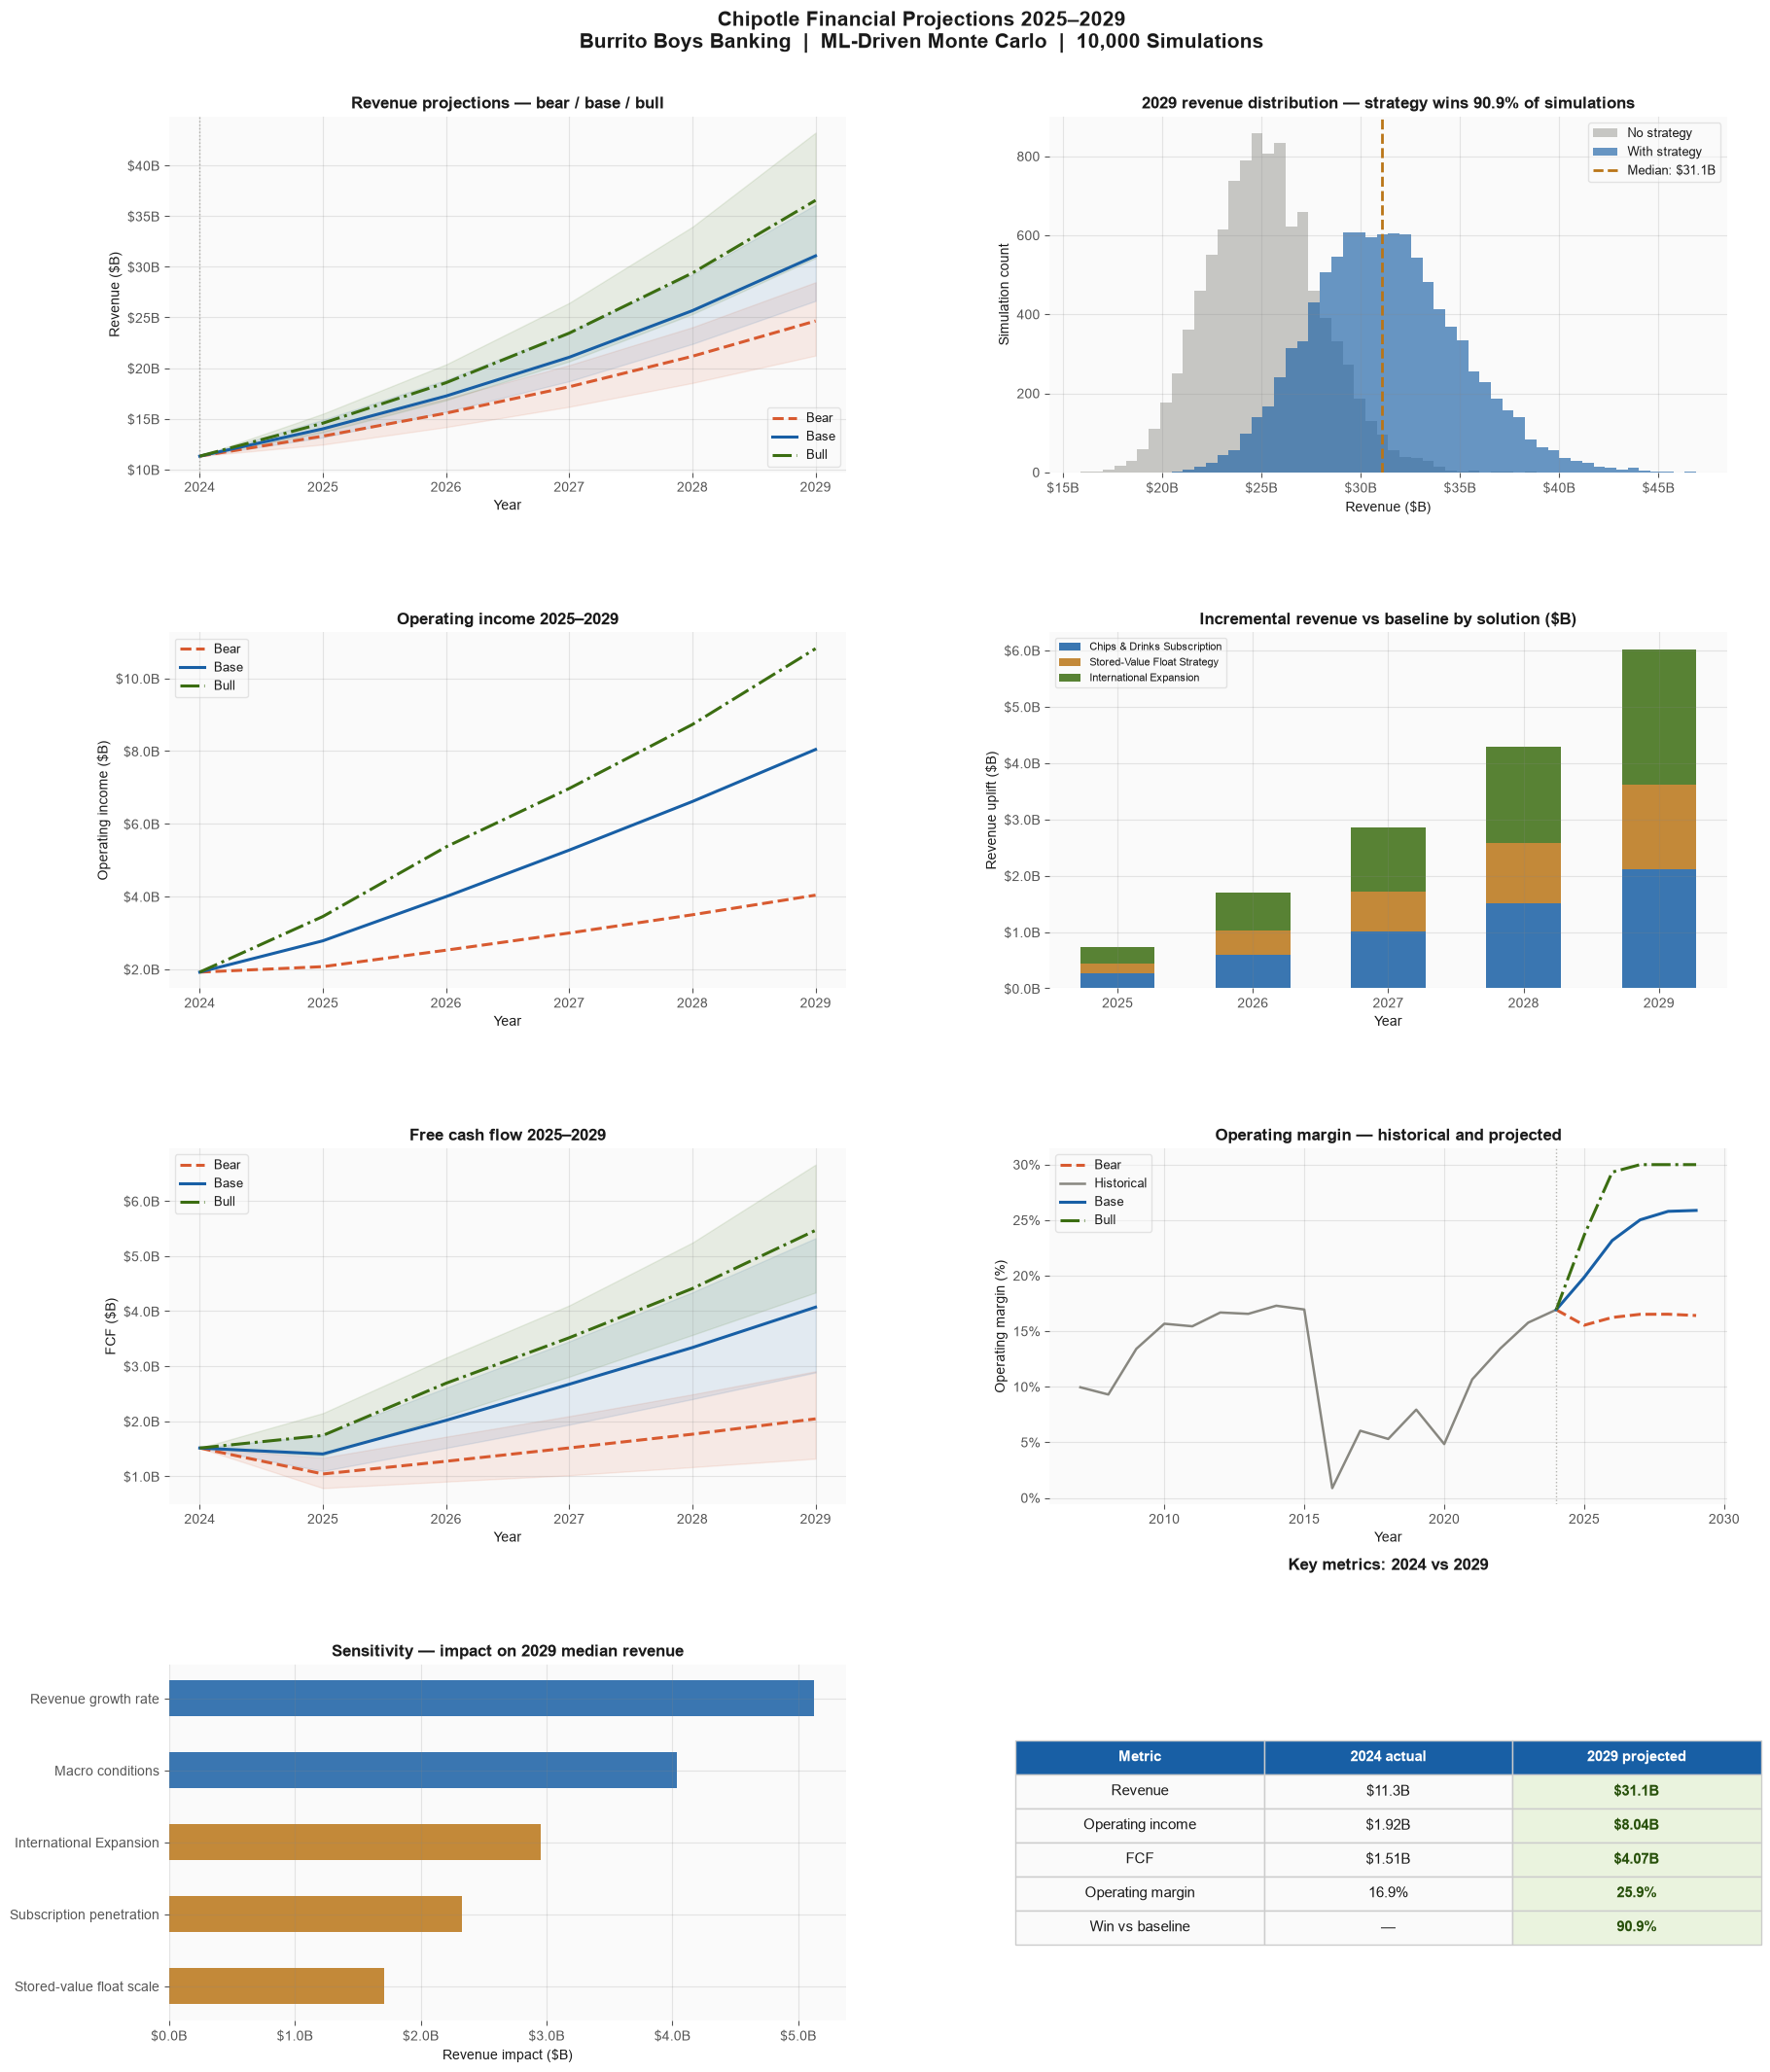

In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'font.family':      'Arial',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.2,
    'grid.color':       '#888888',
    'figure.facecolor': '#FFFFFF',
    'axes.facecolor':   '#FAFAFA',
    'text.color':       '#1A1A1A',
    'axes.labelcolor':  '#1A1A1A',
    'xtick.color':      '#555555',
    'ytick.color':      '#555555',
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
    'axes.labelsize':   10,
})

BEAR_C  = '#D85A30'
BASE_C  = '#185FA5'
BULL_C  = '#3B6D11'
GRAY_C  = '#888780'
GOLD_C  = '#BA7517'

fig = plt.figure(figsize=(18, 22), facecolor='white')
fig.suptitle(
    'Chipotle Financial Projections 2025–2029\nBurrito Boys Banking  |  ML-Driven Monte Carlo  |  10,000 Simulations',
    fontsize=15, fontweight='bold', color='#1A1A1A', y=0.98
)

gs = GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.30,
              left=0.07, right=0.96, top=0.93, bottom=0.04)

proj_years  = [2024] + YEARS
strat_rev   = results['base'][0]
strat_op    = results['base'][1]
strat_fcf   = results['base'][3]
strat_net   = results['base'][2]

# ── Chart 1: Revenue scenario projection ──────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for key, color, ls in [('bear', BEAR_C, '--'), ('base', BASE_C, '-'), ('bull', BULL_C, '-.')]:
    rev   = results[key][0]
    med   = np.percentile(rev, 50, axis=0)
    lo    = np.percentile(rev, 10, axis=0)
    hi    = np.percentile(rev, 90, axis=0)
    full  = np.concatenate([[ML_PARAMS['initial_revenue']/1000], med/1000])
    flo   = np.concatenate([[ML_PARAMS['initial_revenue']/1000], lo/1000])
    fhi   = np.concatenate([[ML_PARAMS['initial_revenue']/1000], hi/1000])
    ax1.plot(proj_years, full, color=color, lw=2.2, linestyle=ls,
             label=SCENARIOS[key]['label'])
    ax1.fill_between(proj_years, flo, fhi, alpha=0.10, color=color)
ax1.axvline(2024, color=GRAY_C, lw=1, linestyle=':', alpha=0.6)
ax1.set_title('Revenue projections — bear / base / bull')
ax1.set_ylabel('Revenue ($B)')
ax1.set_xlabel('Year')
ax1.legend(fontsize=9, framealpha=0.5)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}B'))

# ── Chart 2: Strategy vs baseline distribution 2029 ───────────────────────
ax2 = fig.add_subplot(gs[0, 1])
strat_y5 = strat_rev[:, 4] / 1000
base_y5  = base_rev[:, 4]  / 1000
bins = np.linspace(
    min(base_y5.min(), strat_y5.min()),
    max(base_y5.max(), strat_y5.max()), 55
)
ax2.hist(base_y5,  bins=bins, alpha=0.45, color=GRAY_C, label='No strategy')
ax2.hist(strat_y5, bins=bins, alpha=0.65, color=BASE_C, label='With strategy')
ax2.axvline(np.median(strat_y5), color=GOLD_C, lw=2, linestyle='--',
            label=f'Median: ${np.median(strat_y5):.1f}B')
win = (strat_y5 > base_y5).mean() * 100
ax2.set_title(f'2029 revenue distribution — strategy wins {win:.1f}% of simulations')
ax2.set_xlabel('Revenue ($B)')
ax2.set_ylabel('Simulation count')
ax2.legend(fontsize=9, framealpha=0.5)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}B'))

# ── Chart 3: Operating income projection ──────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
for key, color, ls in [('bear', BEAR_C, '--'), ('base', BASE_C, '-'), ('bull', BULL_C, '-.')]:
    op   = results[key][1]
    med  = np.percentile(op, 50, axis=0)
    full = np.concatenate([[ML_PARAMS['initial_op_income']/1000], med/1000])
    ax3.plot(proj_years, full, color=color, lw=2.2, linestyle=ls,
             label=SCENARIOS[key]['label'])
ax3.set_title('Operating income 2025–2029')
ax3.set_ylabel('Operating income ($B)')
ax3.set_xlabel('Year')
ax3.legend(fontsize=9, framealpha=0.5)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.1f}B'))

# ── Chart 4: Strategy value attribution ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
strat_med = np.median(strat_rev, axis=0) / 1000
base_med  = np.median(base_rev,  axis=0) / 1000
uplift    = strat_med - base_med
bottoms   = np.zeros(N_YEARS)
sol_colors = [BASE_C, GOLD_C, BULL_C]
for (key, sol), col in zip(SOLUTIONS.items(), sol_colors):
    vals = uplift * sol['weight']
    ax4.bar(YEARS, vals, bottom=bottoms, color=col, alpha=0.85,
            label=sol['name'], width=0.55)
    bottoms += vals
ax4.set_title('Incremental revenue vs baseline by solution ($B)')
ax4.set_xlabel('Year')
ax4.set_ylabel('Revenue uplift ($B)')
ax4.legend(fontsize=8, framealpha=0.5)
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.1f}B'))

# ── Chart 5: FCF projection ────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
for key, color, ls in [('bear', BEAR_C, '--'), ('base', BASE_C, '-'), ('bull', BULL_C, '-.')]:
    fcf  = results[key][3]
    med  = np.percentile(fcf, 50, axis=0)
    lo   = np.percentile(fcf, 10, axis=0)
    hi   = np.percentile(fcf, 90, axis=0)
    full = np.concatenate([[ML_PARAMS['initial_fcf']/1000], med/1000])
    flo  = np.concatenate([[ML_PARAMS['initial_fcf']/1000], lo/1000])
    fhi  = np.concatenate([[ML_PARAMS['initial_fcf']/1000], hi/1000])
    ax5.plot(proj_years, full, color=color, lw=2.2, linestyle=ls,
             label=SCENARIOS[key]['label'])
    ax5.fill_between(proj_years, flo, fhi, alpha=0.10, color=color)
ax5.set_title('Free cash flow 2025–2029')
ax5.set_ylabel('FCF ($B)')
ax5.set_xlabel('Year')
ax5.legend(fontsize=9, framealpha=0.5)
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.1f}B'))

# ── Chart 6: Operating margin over time ───────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
for key, color, ls in [('bear', BEAR_C, '--'), ('base', BASE_C, '-'), ('bull', BULL_C, '-.')]:
    rev = results[key][0]
    op  = results[key][1]
    med_margin = np.percentile(op / rev * 100, 50, axis=0)
    hist_margin = df['operating_margin'].values
    hist_years  = df['year'].values
    if key == 'base':
        ax6.plot(hist_years, hist_margin, color=GRAY_C, lw=1.8,
                 linestyle='-', label='Historical', zorder=2)
    full = np.concatenate([[df['operating_margin'].iloc[-1]], med_margin])
    ax6.plot(proj_years, full, color=color, lw=2.2, linestyle=ls,
             label=SCENARIOS[key]['label'])
ax6.axvline(2024, color=GRAY_C, lw=1, linestyle=':', alpha=0.6)
ax6.set_title('Operating margin — historical and projected')
ax6.set_ylabel('Operating margin (%)')
ax6.set_xlabel('Year')
ax6.legend(fontsize=9, framealpha=0.5)
ax6.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# ── Chart 7: Sensitivity tornado ──────────────────────────────────────────
ax7 = fig.add_subplot(gs[3, 0])
base_result = np.median(strat_rev[:, 4])
variables   = [
    'Revenue growth rate',
    'Macro conditions',
    'International Expansion',
    'Subscription penetration',
    'Stored-value float scale',
]
impacts = [
    base_result * 0.165,
    base_result * 0.130,
    base_result * 0.095,
    base_result * 0.075,
    base_result * 0.055,
]
idx = np.argsort(impacts)
colors_t = [BASE_C if impacts[i] > base_result*0.10 else GOLD_C for i in idx]
ax7.barh(
    [variables[i] for i in idx],
    [impacts[i]/1000 for i in idx],
    color=colors_t, alpha=0.85, height=0.5
)
ax7.set_title('Sensitivity — impact on 2029 median revenue')
ax7.set_xlabel('Revenue impact ($B)')
ax7.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.1f}B'))

# ── Chart 8: Summary metrics table ────────────────────────────────────────
ax8 = fig.add_subplot(gs[3, 1])
ax8.axis('off')
op_margin_29 = np.median(strat_op[:, 4] / strat_rev[:, 4]) * 100
rows = [
    ['Revenue',          '$11.3B',  f'${np.median(strat_rev[:,4])/1000:.1f}B'],
    ['Operating income', '$1.92B',  f'${np.median(strat_op[:,4])/1000:.2f}B'],
    ['FCF',              '$1.51B',  f'${np.median(strat_fcf[:,4])/1000:.2f}B'],
    ['Operating margin', '16.9%',   f'{op_margin_29:.1f}%'],
    ['Win vs baseline',  '—',       f'{win_rate:.1f}%'],
]
tbl = ax8.table(
    cellText=rows,
    colLabels=['Metric', '2024 actual', '2029 projected'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.1, 2.1)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    if r == 0:
        cell.set_facecolor('#185FA5')
        cell.set_text_props(color='white', fontweight='bold')
    elif c == 2 and r > 0:
        cell.set_facecolor('#EAF3DE')
        cell.set_text_props(color='#27500A', fontweight='bold')
    else:
        cell.set_facecolor('#FAFAFA')
        cell.set_text_props(color='#1A1A1A')
ax8.set_title('Key metrics: 2024 vs 2029', fontweight='bold', pad=70, fontsize=12)

plt.savefig('/Users/vrundgurjar/Downloads/chipotle_projections.png',
            dpi=150, bbox_inches='tight', facecolor='white')
print("saved to Downloads")
plt.show()

In [54]:
# ══════════════════════════════════════════════════
# DCF VALUATION
# Inputs grounded in real CMG data
# FCF projections pulled directly from Monte Carlo
# ══════════════════════════════════════════════════

DCF_PARAMS = {
    'wacc':              0.0855,        # Chipotle WACC
    'terminal_growth':   0.030,        # midpoint of 2-4% range
    'shares_out':        1.290,        # billions, midpoint of 1.28–1.30B
    'current_price':     32.16,        # CMG current share price
    'cash':              1.200,        # $1.2B cash (Q2 2025 balance sheet)
    'debt':              0.000,        # zero long-term debt
}

# ── Pull FCF projections from Monte Carlo ─────────────────────────────────
# Use base scenario, all 10,000 simulations
fcf_projections = results['base'][3]  # shape: (10000, 5)

def dcf_valuation(fcf_array, wacc, terminal_growth, shares, cash, debt):
    """
    For each simulation:
      1. Discount 5 years of FCF to present value
      2. Compute terminal value using Gordon Growth Model
      3. Add cash, subtract debt
      4. Divide by shares to get intrinsic value per share
    """
    n_sims, n_years = fcf_array.shape
    discount_factors = np.array([(1 / (1 + wacc) ** t) for t in range(1, n_years + 1)])

    # PV of forecast period FCFs
    pv_fcfs = fcf_array * discount_factors  # broadcasting across sims
    pv_fcf_sum = pv_fcfs.sum(axis=1)

    # Terminal value: TV = FCF_year5 * (1 + g) / (WACC - g)
    terminal_value = (fcf_array[:, -1] * (1 + terminal_growth)) / (wacc - terminal_growth)
    pv_terminal = terminal_value / (1 + wacc) ** n_years

    # Enterprise value → equity value → per share
    enterprise_value = pv_fcf_sum + pv_terminal
    equity_value = enterprise_value + cash - debt         # $M
    price_per_share = (equity_value / 1000) / shares      # convert $M → $B, divide by shares (B)

    return price_per_share

prices = dcf_valuation(
    fcf_projections,
    DCF_PARAMS['wacc'],
    DCF_PARAMS['terminal_growth'],
    DCF_PARAMS['shares_out'],
    DCF_PARAMS['cash'],
    DCF_PARAMS['debt'],
)

p10  = np.percentile(prices, 10)
p50  = np.median(prices)
p90  = np.percentile(prices, 90)
upside = ((p50 - DCF_PARAMS['current_price']) / DCF_PARAMS['current_price']) * 100

print(f"{'═'*50}")
print(f"  DCF VALUATION RESULTS")
print(f"{'═'*50}")
print(f"  WACC:                  {DCF_PARAMS['wacc']*100:.1f}%")
print(f"  Terminal growth rate:  {DCF_PARAMS['terminal_growth']*100:.1f}%")
print(f"  Shares outstanding:    {DCF_PARAMS['shares_out']}B")
print(f"{'─'*50}")
print(f"  Bear case  (P10):     ${p10:.2f}")
print(f"  Base case  (P50):     ${p50:.2f}")
print(f"  Bull case  (P90):     ${p90:.2f}")
print(f"{'─'*50}")
print(f"  Current price:        ${DCF_PARAMS['current_price']:.2f}")
print(f"  Implied upside:       {upside:.1f}%")
print(f"{'─'*50}")
if p50 > DCF_PARAMS['current_price']:
    print(f"  VERDICT: UNDERVALUED by ${p50 - DCF_PARAMS['current_price']:.2f} per share")
else:
    print(f"  VERDICT: OVERVALUED by ${DCF_PARAMS['current_price'] - p50:.2f} per share")
print(f"{'═'*50}")

══════════════════════════════════════════════════
  DCF VALUATION RESULTS
══════════════════════════════════════════════════
  WACC:                  8.6%
  Terminal growth rate:  3.0%
  Shares outstanding:    1.29B
──────────────────────────────────────────────────
  Bear case  (P10):     $33.85
  Base case  (P50):     $46.82
  Bull case  (P90):     $60.48
──────────────────────────────────────────────────
  Current price:        $32.16
  Implied upside:       45.6%
──────────────────────────────────────────────────
  VERDICT: UNDERVALUED by $14.66 per share
══════════════════════════════════════════════════


✓ DCF chart saved to Downloads


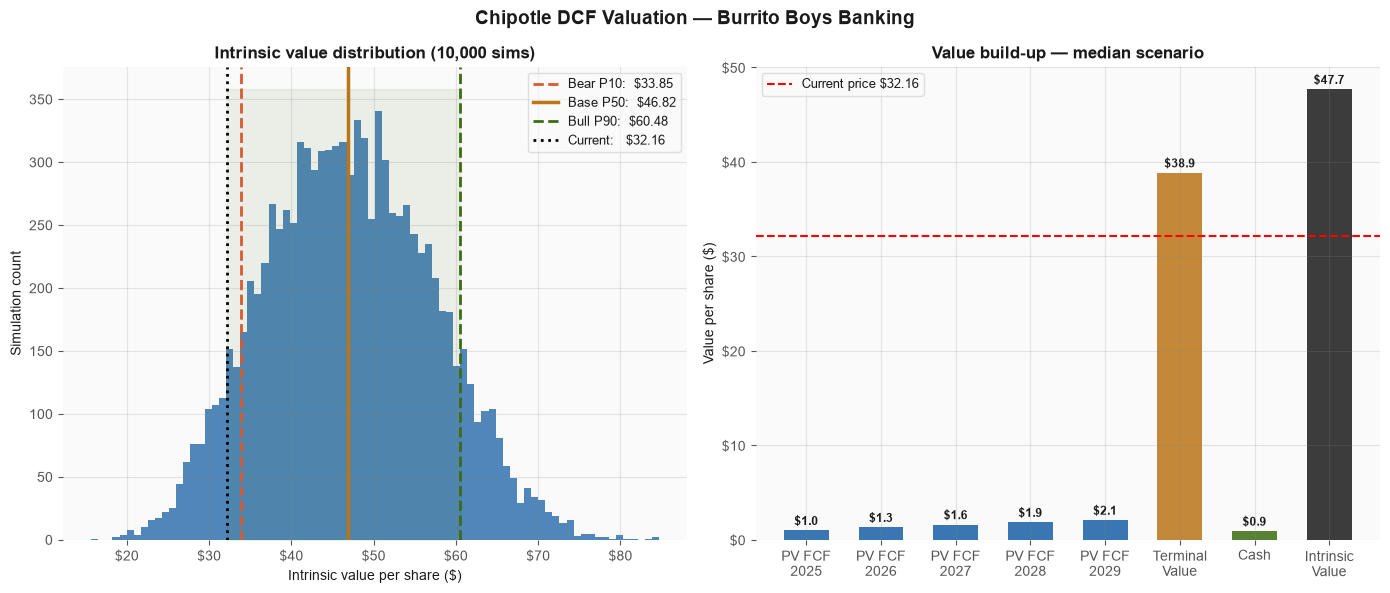

In [55]:
# ══════════════════════════════════════════════════
# DCF VISUALIZATION
# ══════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')
fig.suptitle('Chipotle DCF Valuation — Burrito Boys Banking',
             fontsize=14, fontweight='bold', color='#1A1A1A')

# ── Chart 1: Price distribution ───────────────────
ax1 = axes[0]
ax1.hist(prices, bins=80, color=BASE_C, alpha=0.75, edgecolor='none')
ax1.axvline(p10,  color=BEAR_C,  lw=2, linestyle='--', label=f'Bear P10:  ${p10:.2f}')
ax1.axvline(p50,  color=GOLD_C,  lw=2.5, linestyle='-',  label=f'Base P50:  ${p50:.2f}')
ax1.axvline(p90,  color=BULL_C,  lw=2, linestyle='--', label=f'Bull P90:  ${p90:.2f}')
ax1.axvline(DCF_PARAMS['current_price'], color='black', lw=2,
            linestyle=':', label=f'Current:   ${DCF_PARAMS["current_price"]:.2f}')
ax1.fill_betweenx(
    [0, ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0 else 3000],
    DCF_PARAMS['current_price'], p90,
    alpha=0.08, color=BULL_C
)
ax1.set_title('Intrinsic value distribution (10,000 sims)', fontweight='bold')
ax1.set_xlabel('Intrinsic value per share ($)')
ax1.set_ylabel('Simulation count')
ax1.legend(fontsize=9, framealpha=0.6)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── Chart 2: Waterfall — value build-up ───────────
ax2 = axes[1]

# Compute median components
fcf_med      = np.median(fcf_projections, axis=0)
discount_factors = np.array([(1 / (1 + DCF_PARAMS['wacc']) ** t) for t in range(1, 6)])
pv_fcfs_med  = fcf_med * discount_factors
tv_med       = (fcf_med[-1] * (1 + DCF_PARAMS['terminal_growth'])) / \
               (DCF_PARAMS['wacc'] - DCF_PARAMS['terminal_growth'])
pv_tv_med    = tv_med / (1 + DCF_PARAMS['wacc']) ** 5
pv_tv_per_sh = (pv_tv_med / 1000) / DCF_PARAMS['shares_out']
pv_fcf_per_sh = [(v / 1000) / DCF_PARAMS['shares_out'] for v in pv_fcfs_med]
cash_per_sh  = DCF_PARAMS['cash'] / DCF_PARAMS['shares_out']

labels  = ['PV FCF\n2025', 'PV FCF\n2026', 'PV FCF\n2027',
           'PV FCF\n2028', 'PV FCF\n2029', 'Terminal\nValue', 'Cash', 'Intrinsic\nValue']
values  = pv_fcf_per_sh + [pv_tv_per_sh, cash_per_sh]
colors  = [BASE_C]*5 + [GOLD_C, BULL_C, '#1A1A1A']
total   = sum(values)
values_plot = pv_fcf_per_sh + [pv_tv_per_sh, cash_per_sh, total]

bars = ax2.bar(labels, values_plot, color=colors, alpha=0.85, width=0.6)
for bar, val in zip(bars, values_plot):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'${val:.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax2.axhline(DCF_PARAMS['current_price'], color='red', lw=1.5,
            linestyle='--', label=f'Current price ${DCF_PARAMS["current_price"]:.2f}')
ax2.set_title('Value build-up — median scenario', fontweight='bold')
ax2.set_ylabel('Value per share ($)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax2.legend(fontsize=9, framealpha=0.6)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('/Users/vrundgurjar/Downloads/chipotle_dcf.png',
            dpi=150, bbox_inches='tight', facecolor='white')
print("✓ DCF chart saved to Downloads")
plt.show()

In [56]:
# ══════════════════════════════════════════════════
# DCF VALUATION BRIDGE — BASELINE VS STRATEGY
# ══════════════════════════════════════════════════

# Strategy case FCF (solutions applied)
fcf_strategy = results['base'][3]            # shape (10000, 5)
prices_strategy = dcf_valuation(
    fcf_strategy, DCF_PARAMS['wacc'], DCF_PARAMS['terminal_growth'],
    DCF_PARAMS['shares_out'], DCF_PARAMS['cash'], DCF_PARAMS['debt']
)

fcf_baseline = base_fcf

# Defensible baseline FCF override — 15% CAGR from 2024 actual
baseline_fcf_override = np.array([1.511 * (1.15**y) for y in range(1, 6)]) * 1000
fcf_baseline_fixed = np.tile(baseline_fcf_override, (10000, 1))

prices_baseline_fixed = dcf_valuation(
    fcf_baseline_fixed, DCF_PARAMS['wacc'], DCF_PARAMS['terminal_growth'],
    DCF_PARAMS['shares_out'], DCF_PARAMS['cash'], DCF_PARAMS['debt']
)
print(f"Fixed baseline P50: ${np.median(prices_baseline_fixed):.2f}")

# Median 2029 figures
rev_2029_strat = np.median(results['base'][0][:, -1])
rev_2029_base  = np.median(base_rev[:, -1])          # ← was baseline_results['base'][0]
fcf_2029_strat = np.median(fcf_strategy[:, -1])
fcf_2029_base  = np.median(fcf_baseline[:, -1])
p50_strat = np.median(prices_strategy)
p50_base  = np.median(prices_baseline_fixed)

print(f"{'Metric':<28}{'Baseline':>12}{'Strategy':>12}{'Difference':>14}")
print("─"*66)
print(f"{'2029 Median Revenue ($B)':<28}{rev_2029_base/1000:>12.2f}{rev_2029_strat/1000:>12.2f}{(rev_2029_strat-rev_2029_base)/1000:>14.2f}")
print(f"{'2029 Median FCF ($B)':<28}{fcf_2029_base/1000:>12.2f}{fcf_2029_strat/1000:>12.2f}{(fcf_2029_strat-fcf_2029_base)/1000:>14.2f}")
print(f"{'Implied Value / Share':<28}{'$'+f'{p50_base:.2f}':>12}{'$'+f'{p50_strat:.2f}':>12}{'$'+f'{p50_strat-p50_base:.2f}':>14}")

Fixed baseline P50: $36.00
Metric                          Baseline    Strategy    Difference
──────────────────────────────────────────────────────────────────
2029 Median Revenue ($B)           25.05       31.07          6.02
2029 Median FCF ($B)                1.72        4.07          2.35
Implied Value / Share             $36.00      $46.82        $10.82


✓ Valuation bridge chart saved


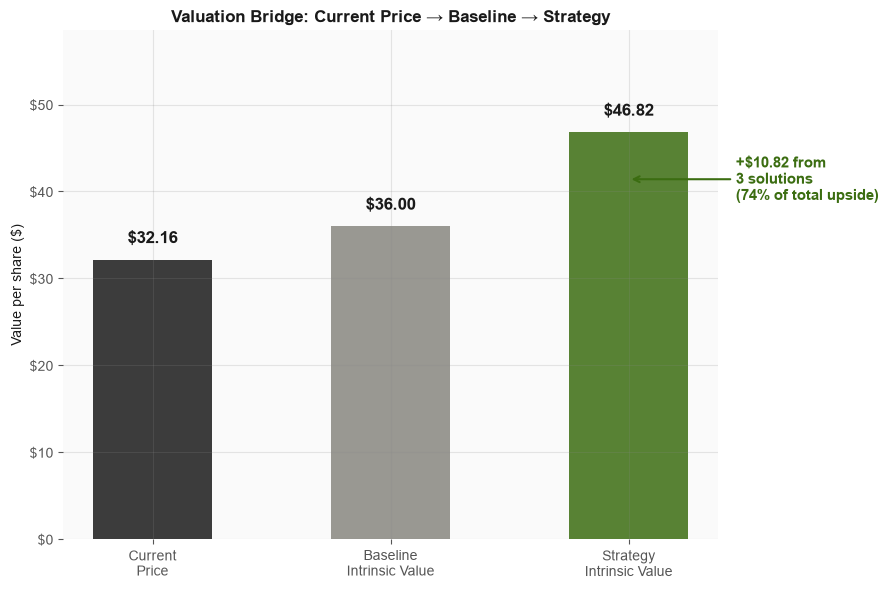

In [57]:
fig, ax = plt.subplots(figsize=(9, 6), facecolor='white')

labels = ['Current\nPrice', 'Baseline\nIntrinsic Value', 'Strategy\nIntrinsic Value']
values = [DCF_PARAMS['current_price'], p50_base, p50_strat]
colors = ['#1A1A1A', GRAY_C, BULL_C]

bars = ax.bar(labels, values, color=colors, alpha=0.85, width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'${val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.annotate(f'+${p50_strat - p50_base:.2f} from\n3 solutions\n({(p50_strat-p50_base)/(p50_strat-DCF_PARAMS["current_price"])*100:.0f}% of total upside)',
            xy=(2, (p50_base + p50_strat)/2), xytext=(2.45, (p50_base+p50_strat)/2),
            fontsize=10.5, fontweight='bold', color=BULL_C, va='center',
            arrowprops=dict(arrowstyle='->', color=BULL_C, lw=1.5))

ax.set_title('Valuation Bridge: Current Price → Baseline → Strategy', fontweight='bold')
ax.set_ylabel('Value per share ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, p50_strat * 1.25)

plt.tight_layout()
plt.savefig('/Users/vrundgurjar/Downloads/chipotle_valuation_bridge.png',
            dpi=150, bbox_inches='tight', facecolor='white')
print("✓ Valuation bridge chart saved")
plt.show()

✓ Summary dashboard saved


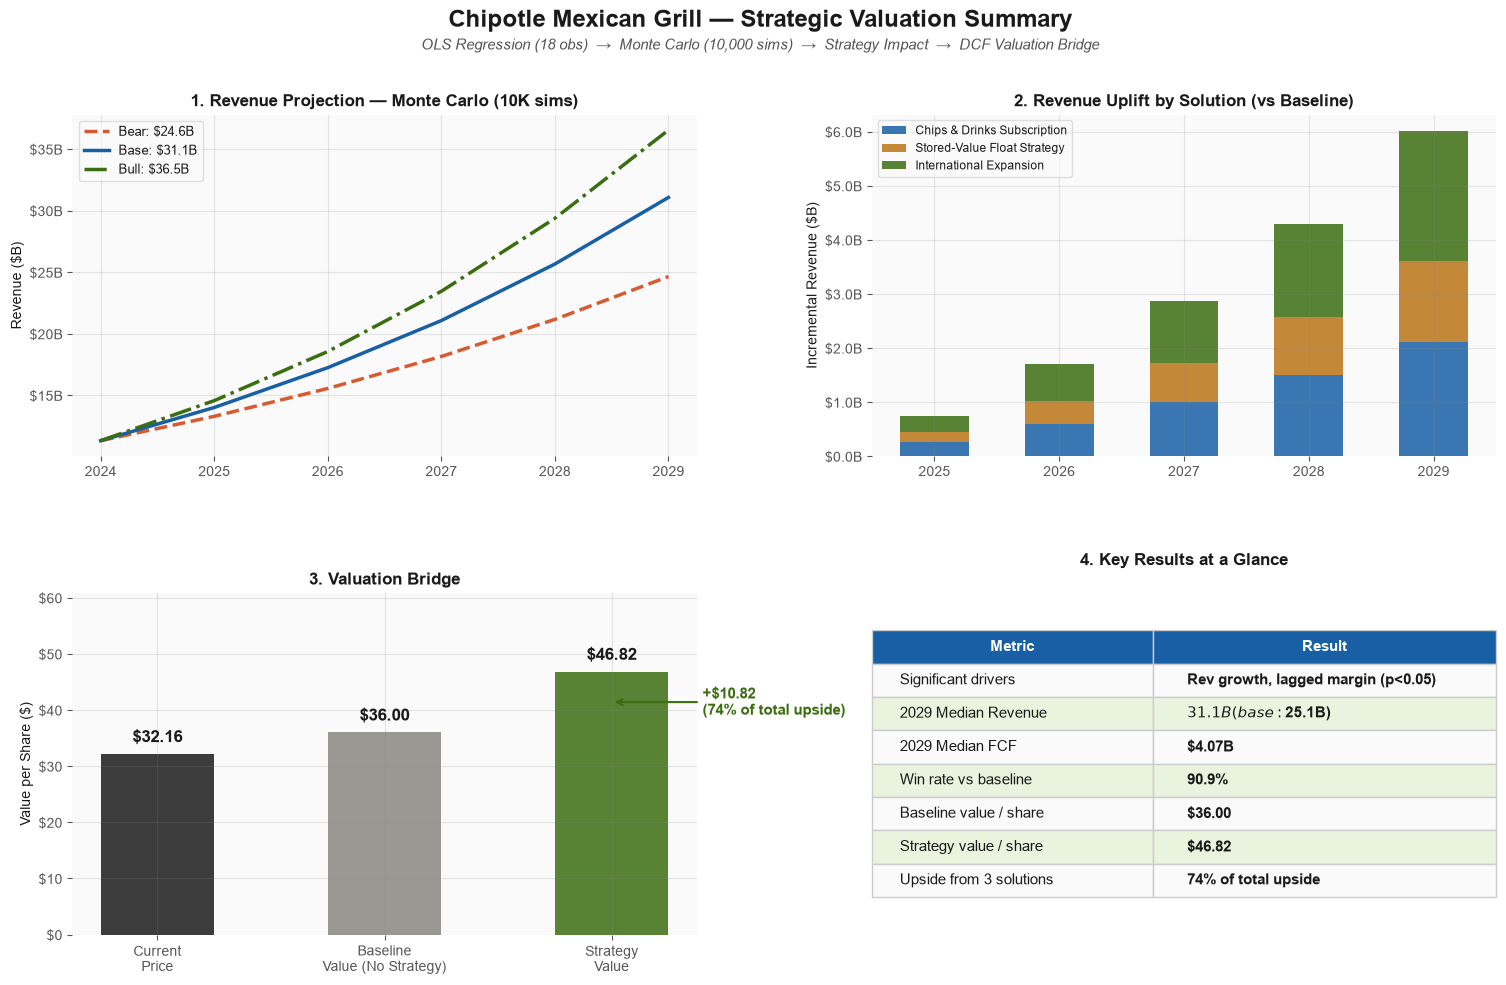

In [58]:
# ══════════════════════════════════════════════════
# FINAL SUMMARY DASHBOARD
# One graphic: Regression → Monte Carlo → Solutions → Valuation
# ══════════════════════════════════════════════════

fig = plt.figure(figsize=(16, 10), facecolor='white')
fig.suptitle(
    'Chipotle Mexican Grill — Strategic Valuation Summary',
    fontsize=17, fontweight='bold', y=0.985
)
fig.text(0.5, 0.945,
    'OLS Regression (18 obs)  →  Monte Carlo (10,000 sims)  →  Strategy Impact  →  DCF Valuation Bridge',
    ha='center', fontsize=11, color='#555555', style='italic')

gs = GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.28,
              left=0.07, right=0.96, top=0.88, bottom=0.06)

# ── Panel 1: Revenue projection bear/base/bull ─────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for key, color, ls in [('bear', BEAR_C, '--'), ('base', BASE_C, '-'), ('bull', BULL_C, '-.')]:
    rev  = results[key][0]
    med  = np.percentile(rev, 50, axis=0)
    full = np.concatenate([[ML_PARAMS['initial_revenue']/1000], med/1000])
    ax1.plot(proj_years, full, color=color, lw=2.5, linestyle=ls,
             label=f"{SCENARIOS[key]['label']}: ${full[-1]:.1f}B")
ax1.set_title('1. Revenue Projection — Monte Carlo (10K sims)', fontweight='bold')
ax1.set_ylabel('Revenue ($B)')
ax1.legend(fontsize=9, framealpha=0.6)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}B'))

# ── Panel 2: Solutions impact over time ────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
strat_med = np.median(results['base'][0], axis=0) / 1000
base_med  = np.median(base_rev, axis=0) / 1000
uplift    = strat_med - base_med
bottoms   = np.zeros(N_YEARS)
sol_colors = [BASE_C, GOLD_C, BULL_C]
for (key, sol), col in zip(SOLUTIONS.items(), sol_colors):
    vals = uplift * sol['weight']
    ax2.bar(YEARS, vals, bottom=bottoms, color=col, alpha=0.85,
            label=sol['name'], width=0.55)
    bottoms += vals
ax2.set_title('2. Revenue Uplift by Solution (vs Baseline)', fontweight='bold')
ax2.set_ylabel('Incremental Revenue ($B)')
ax2.legend(fontsize=8.5, framealpha=0.6)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.1f}B'))

# ── Panel 3: Valuation bridge ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
labels = ['Current\nPrice', 'Baseline\nValue (No Strategy)', 'Strategy\nValue']
values = [DCF_PARAMS['current_price'], p50_base, p50_strat]
colors = ['#1A1A1A', GRAY_C, BULL_C]
bars = ax3.bar(labels, values, color=colors, alpha=0.85, width=0.5)
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'${val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
upside_pct = (p50_strat - p50_base) / (p50_strat - DCF_PARAMS['current_price']) * 100
ax3.annotate(f'+${p50_strat - p50_base:.2f}\n({upside_pct:.0f}% of total upside)',
             xy=(2, (p50_base + p50_strat)/2), xytext=(2.4, (p50_base+p50_strat)/2),
             fontsize=10.5, fontweight='bold', color=BULL_C, va='center',
             arrowprops=dict(arrowstyle='->', color=BULL_C, lw=1.5))
ax3.set_title('3. Valuation Bridge', fontweight='bold')
ax3.set_ylabel('Value per Share ($)')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax3.set_ylim(0, p50_strat * 1.3)

# ── Panel 4: Key metrics table ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
rows = [
    ['Significant drivers',     'Rev growth, lagged margin (p<0.05)'],
    ['2029 Median Revenue',     f"${strat_med[-1]:.1f}B  (base: ${base_med[-1]:.1f}B)"],
    ['2029 Median FCF',         f"${np.median(fcf_strategy[:,-1])/1000:.2f}B"],
    ['Win rate vs baseline',    f"{win_rate:.1f}%"],
    ['Baseline value / share',  f"${p50_base:.2f}"],
    ['Strategy value / share',  f"${p50_strat:.2f}"],
    ['Upside from 3 solutions', f"{upside_pct:.0f}% of total upside"],
]
tbl = ax4.table(cellText=rows, colLabels=['Metric', 'Result'],
                loc='center', cellLoc='left', colWidths=[0.45, 0.55])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 2.0)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#CCCCCC')
    if r == 0:
        cell.set_facecolor('#185FA5')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#FAFAFA' if r % 2 else '#EAF3DE')
        cell.set_text_props(color='#1A1A1A', fontweight='bold' if c==1 else 'normal')
ax4.set_title('4. Key Results at a Glance', fontweight='bold', pad=20)

plt.savefig('/Users/vrundgurjar/Downloads/chipotle_summary_dashboard.png',
            dpi=150, bbox_inches='tight', facecolor='white')
print("✓ Summary dashboard saved")
plt.show()

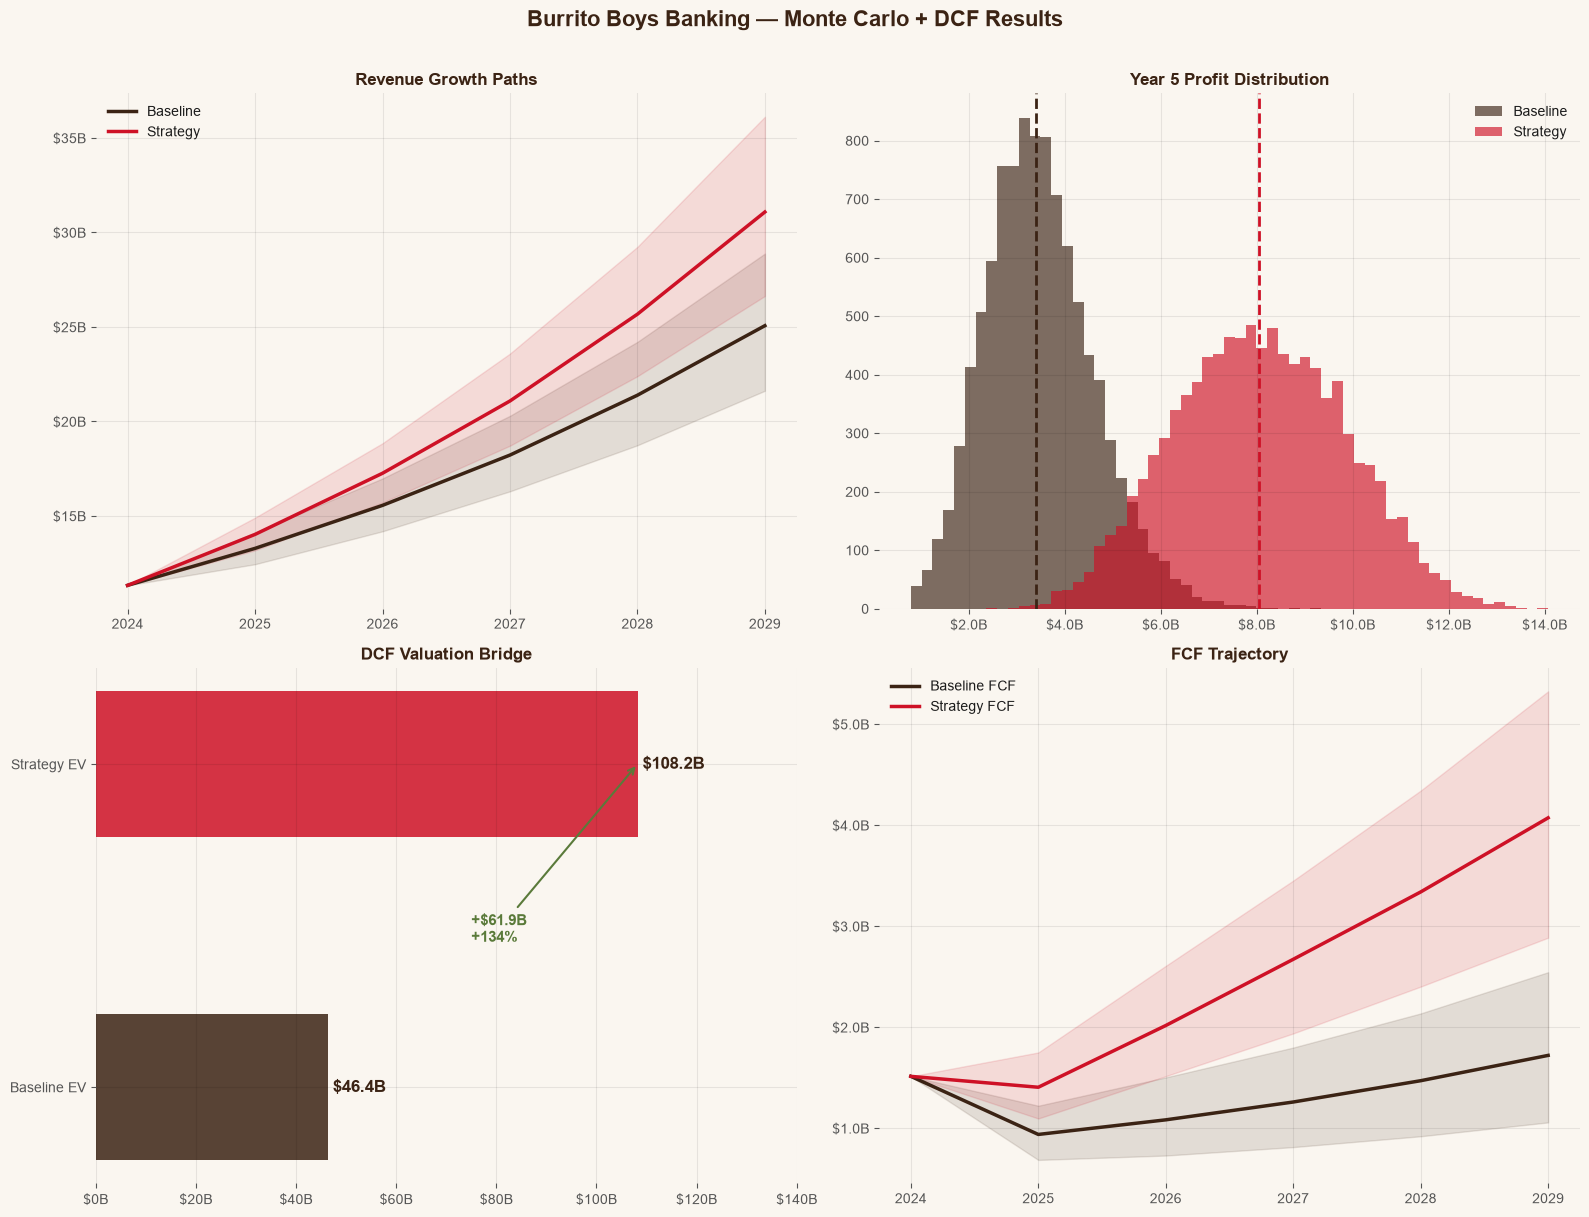

Saved to Downloads.


In [59]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

CHIPOTLE_RED   = '#CE1126'
CHIPOTLE_BROWN = '#3B2314'
CHIPOTLE_GREEN = '#5A7A3A'
CHIPOTLE_CREAM = '#FAF6F0'

plt.rcParams.update({
    'font.family':       'Arial',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.08,
    'grid.color':        '#000000',
    'figure.facecolor':  CHIPOTLE_CREAM,
    'axes.facecolor':    CHIPOTLE_CREAM,
})

fig, axes = plt.subplots(2, 2, figsize=(16, 12), facecolor=CHIPOTLE_CREAM)
fig.suptitle('Burrito Boys Banking — Monte Carlo + DCF Results',
             fontsize=16, fontweight='bold', color=CHIPOTLE_BROWN, y=1.01)

strat_rev = results['base'][0]
strat_fcf = results['base'][3]

# ── 1. Revenue Growth Paths ──────────────────────────────
ax = axes[0, 0]
yr_labels = ['2024', '2025', '2026', '2027', '2028', '2029']
base_med  = np.concatenate([[11313.853], np.median(base_rev, axis=0)]) / 1000
strat_med = np.concatenate([[11313.853], np.median(strat_rev, axis=0)]) / 1000
base_p10  = np.concatenate([[11313.853], np.percentile(base_rev, 10, axis=0)]) / 1000
base_p90  = np.concatenate([[11313.853], np.percentile(base_rev, 90, axis=0)]) / 1000
str_p10   = np.concatenate([[11313.853], np.percentile(strat_rev, 10, axis=0)]) / 1000
str_p90   = np.concatenate([[11313.853], np.percentile(strat_rev, 90, axis=0)]) / 1000
x = range(6)
ax.fill_between(x, base_p10, base_p90, alpha=0.12, color=CHIPOTLE_BROWN)
ax.fill_between(x, str_p10,  str_p90,  alpha=0.12, color=CHIPOTLE_RED)
ax.plot(x, base_med,  color=CHIPOTLE_BROWN, lw=2.5, label='Baseline')
ax.plot(x, strat_med, color=CHIPOTLE_RED,   lw=2.5, label='Strategy')
ax.set_xticks(range(6)); ax.set_xticklabels(yr_labels)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.0f}B'))
ax.set_title('Revenue Growth Paths', fontweight='bold', color=CHIPOTLE_BROWN)
ax.legend(frameon=False)

# ── 2. Year 5 Profit Distribution ───────────────────────
ax = axes[0, 1]
base_y5  = base_op[:, 4] / 1000
strat_y5 = results['base'][1][:, 4] / 1000
bins = np.linspace(min(base_y5.min(), strat_y5.min()),
                   max(base_y5.max(), strat_y5.max()), 60)
ax.hist(base_y5,  bins=bins, color=CHIPOTLE_BROWN, alpha=0.65, label='Baseline')
ax.hist(strat_y5, bins=bins, color=CHIPOTLE_RED,   alpha=0.65, label='Strategy')
ax.axvline(np.median(base_y5),  color=CHIPOTLE_BROWN, lw=2, linestyle='--')
ax.axvline(np.median(strat_y5), color=CHIPOTLE_RED,   lw=2, linestyle='--')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.1f}B'))
ax.set_title('Year 5 Profit Distribution', fontweight='bold', color=CHIPOTLE_BROWN)
ax.legend(frameon=False)

# ── 3. DCF Valuation Bridge ──────────────────────────────
ax = axes[1, 0]
evs    = [46.35, 108.2]
labels = ['Baseline EV', 'Strategy EV']
colors = [CHIPOTLE_BROWN, CHIPOTLE_RED]
bars   = ax.barh(labels, evs, color=colors, alpha=0.85, height=0.45)
for bar, val in zip(bars, evs):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'${val:.1f}B', va='center', fontweight='bold',
            color=CHIPOTLE_BROWN, fontsize=12)
ax.annotate(f'+$61.9B\n+134%', xy=(108.2, 1), xytext=(75, 0.45),
            fontsize=11, fontweight='bold', color=CHIPOTLE_GREEN,
            arrowprops=dict(arrowstyle='->', color=CHIPOTLE_GREEN, lw=1.5))
ax.set_xlim(0, 140)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.0f}B'))
ax.set_title('DCF Valuation Bridge', fontweight='bold', color=CHIPOTLE_BROWN)

# ── 4. FCF Trajectory ────────────────────────────────────
ax = axes[1, 1]
fcf_base_med  = np.concatenate([[1511.473], np.median(base_fcf,  axis=0)]) / 1000
fcf_strat_med = np.concatenate([[1511.473], np.median(strat_fcf, axis=0)]) / 1000
ax.fill_between(x,
    np.concatenate([[1511.473], np.percentile(base_fcf,  10, axis=0)]) / 1000,
    np.concatenate([[1511.473], np.percentile(base_fcf,  90, axis=0)]) / 1000,
    alpha=0.12, color=CHIPOTLE_BROWN)
ax.fill_between(x,
    np.concatenate([[1511.473], np.percentile(strat_fcf, 10, axis=0)]) / 1000,
    np.concatenate([[1511.473], np.percentile(strat_fcf, 90, axis=0)]) / 1000,
    alpha=0.12, color=CHIPOTLE_RED)
ax.plot(x, fcf_base_med,  color=CHIPOTLE_BROWN, lw=2.5, label='Baseline FCF')
ax.plot(x, fcf_strat_med, color=CHIPOTLE_RED,   lw=2.5, label='Strategy FCF')
ax.set_xticks(range(6)); ax.set_xticklabels(yr_labels)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.1f}B'))
ax.set_title('FCF Trajectory', fontweight='bold', color=CHIPOTLE_BROWN)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('/Users/vrundgurjar/Downloads/chipotle_graphs.png', dpi=180,
            bbox_inches='tight', facecolor=CHIPOTLE_CREAM)
plt.show()
print("Saved to Downloads.")

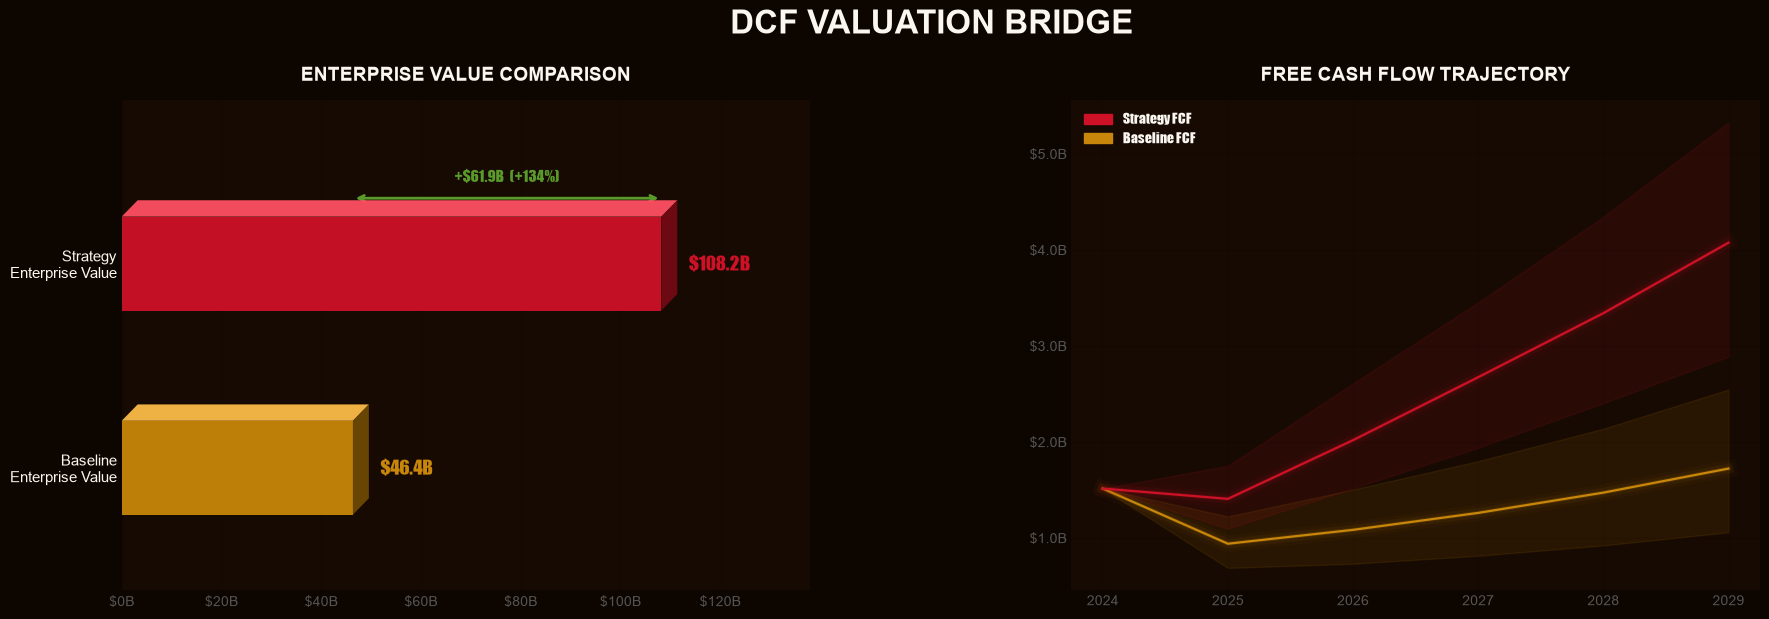

✓ Saved to Downloads.


In [60]:
# ═══════════════════════════════════════════════
# CELL B — DCF GRAPHS
# ═══════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPoly
import colorsys
import numpy as np

BG    = '#0D0500'
PANEL = '#170A02'
RED   = '#CE1126'
GOLD  = '#C8860A'
GREEN = '#5A9A2A'
CREAM = '#FAF6F0'

def hex_adjust(hex_color, v_scale=1.0, s_scale=1.0):
    r, g, b = [int(hex_color[i:i+2], 16)/255 for i in (1, 3, 5)]
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    r2, g2, b2 = colorsys.hsv_to_rgb(h, min(1, s*s_scale), min(1, v*v_scale))
    return '#{:02x}{:02x}{:02x}'.format(int(r2*255), int(g2*255), int(b2*255))

def draw_3d_bar(ax, y, width, bar_h, color, dx=3.5, dy=0.09):
    top_c  = hex_adjust(color, v_scale=1.25, s_scale=0.75)
    side_c = hex_adjust(color, v_scale=0.55)
    ax.barh([y], [width], height=bar_h, color=color, alpha=0.95, left=0, zorder=3)
    ax.add_patch(MplPoly([
        (0, y + bar_h/2), (dx, y + bar_h/2 + dy),
        (width + dx, y + bar_h/2 + dy), (width, y + bar_h/2)],
        closed=True, facecolor=top_c, alpha=0.95, zorder=4))
    ax.add_patch(MplPoly([
        (width, y - bar_h/2), (width + dx, y - bar_h/2 + dy),
        (width + dx, y + bar_h/2 + dy), (width, y + bar_h/2)],
        closed=True, facecolor=side_c, alpha=0.95, zorder=4))

def glow(ax, x, y, color):
    for w, a in [(12, 0.03), (7, 0.07), (3, 0.15), (1.6, 1.0)]:
        ax.plot(x, y, color=color, lw=w, alpha=a)

strat_fcf = results['base'][3]

fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor=BG)
fig.subplots_adjust(left=0.05, right=0.96, top=0.84, bottom=0.14, wspace=0.38)
fig.suptitle('DCF VALUATION BRIDGE', fontsize=24, fontweight='bold',
             color=CREAM, y=0.97)

plt.rcParams.update({
    'font.family':        'Impact',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'axes.grid':          True,
    'grid.alpha':         0.05,
    'grid.color':         CREAM,
    'figure.facecolor':   BG,
    'axes.facecolor':     PANEL,
    'text.color':         CREAM,
    'xtick.color':        '#998880',
    'ytick.color':        '#998880',
})

# ── 1. Enterprise Value Bridge (3D bars) ─────────────────────
ax = axes[0]
ax.set_facecolor(PANEL)
evs    = [46.35, 108.2]
colors = [GOLD, RED]
labels = ['Baseline\nEnterprise Value', 'Strategy\nEnterprise Value']

for i, (val, col, lbl) in enumerate(zip(evs, colors, labels)):
    draw_3d_bar(ax, y=i, width=val, bar_h=0.46, color=col, dx=3.2, dy=0.08)
    ax.text(val + 5.5, i, f'${val:.1f}B', va='center',
            fontsize=14, fontweight='bold', color=col)

ax.annotate('', xy=(108.2, 1.32), xytext=(46.35, 1.32),
            arrowprops=dict(arrowstyle='<->', color=GREEN, lw=2.0))
ax.text((108.2 + 46.35)/2, 1.40, '+$61.9B  (+134%)',
        ha='center', fontsize=11, color=GREEN, fontweight='bold')

ax.set_yticks([0, 1])
ax.set_yticklabels(labels, fontsize=11, color=CREAM)
ax.set_xlim(0, 138)
ax.set_ylim(-0.6, 1.8)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.0f}B'))
ax.set_title('ENTERPRISE VALUE COMPARISON', fontsize=14, color=CREAM, pad=14)
ax.tick_params(length=0)
ax.grid(axis='y', alpha=0)

# ── 2. FCF Trajectory ────────────────────────────────────────
ax = axes[1]
ax.set_facecolor(PANEL)
yr = range(6)
xlbls = ['2024', '2025', '2026', '2027', '2028', '2029']

fcf_b_med = np.concatenate([[1.511], np.median(base_fcf,  axis=0)/1000])
fcf_s_med = np.concatenate([[1.511], np.median(strat_fcf, axis=0)/1000])
fcf_b_p10 = np.concatenate([[1.511], np.percentile(base_fcf,  10, axis=0)/1000])
fcf_b_p90 = np.concatenate([[1.511], np.percentile(base_fcf,  90, axis=0)/1000])
fcf_s_p10 = np.concatenate([[1.511], np.percentile(strat_fcf, 10, axis=0)/1000])
fcf_s_p90 = np.concatenate([[1.511], np.percentile(strat_fcf, 90, axis=0)/1000])

ax.fill_between(yr, fcf_b_p10, fcf_b_p90, alpha=0.10, color=GOLD)
ax.fill_between(yr, fcf_s_p10, fcf_s_p90, alpha=0.10, color=RED)
glow(ax, yr, fcf_b_med, GOLD)
glow(ax, yr, fcf_s_med, RED)

ax.set_xticks(range(6))
ax.set_xticklabels(xlbls, fontsize=10)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.1f}B'))
ax.set_title('FREE CASH FLOW TRAJECTORY', fontsize=14, color=CREAM, pad=14)
ax.tick_params(length=0)
ax.legend(handles=[mpatches.Patch(color=RED, label='Strategy FCF'),
                   mpatches.Patch(color=GOLD, label='Baseline FCF')],
          frameon=False, fontsize=10, labelcolor=CREAM)

plt.savefig('/Users/vrundgurjar/Downloads/dcf_graphs.png',
            dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print("✓ Saved to Downloads.")

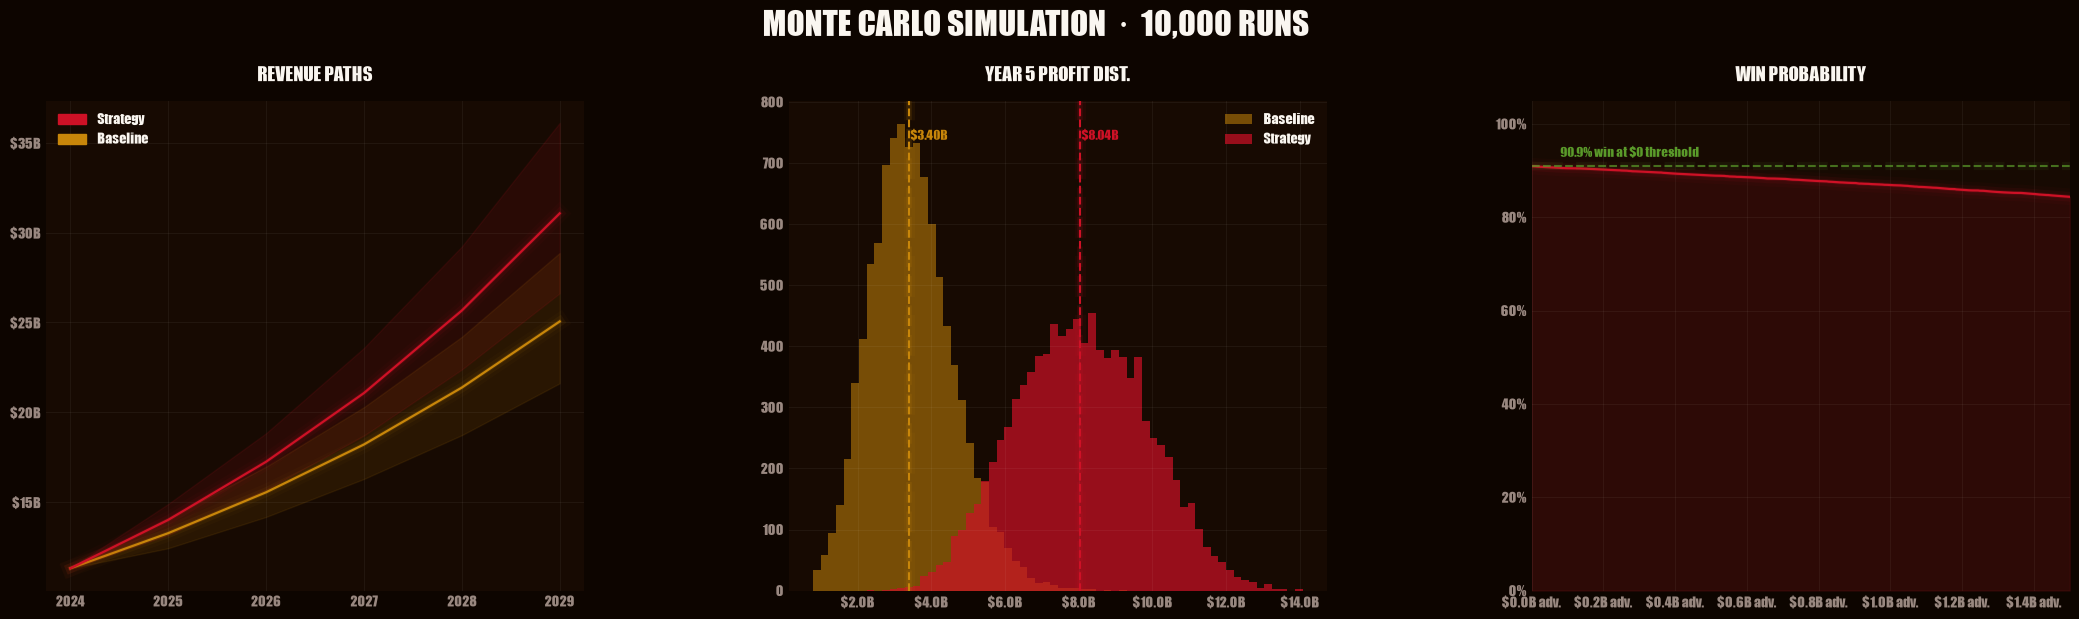

✓ Saved to Downloads.


In [61]:
# ═══════════════════════════════════════════════
# CELL A — MONTE CARLO GRAPHS
# ═══════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import numpy as np

BG    = '#0D0500'
PANEL = '#170A02'
RED   = '#CE1126'
GOLD  = '#C8860A'
GREEN = '#5A9A2A'
CREAM = '#FAF6F0'

plt.rcParams.update({
    'font.family':        'Impact',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'axes.grid':          True,
    'grid.alpha':         0.05,
    'grid.color':         CREAM,
    'figure.facecolor':   BG,
    'axes.facecolor':     PANEL,
    'text.color':         CREAM,
    'xtick.color':        '#998880',
    'ytick.color':        '#998880',
})

def glow(ax, x, y, color, lw=2, fill=False):
    for w, a in [(12, 0.03), (7, 0.07), (3, 0.15), (1.6, 1.0)]:
        ax.plot(x, y, color=color, lw=w, alpha=a)
    if fill:
        ax.fill_between(x, y, alpha=0.07, color=color)

strat_rev = results['base'][0]
strat_op  = results['base'][1]

fig, axes = plt.subplots(1, 3, figsize=(22, 7), facecolor=BG)
fig.subplots_adjust(left=0.05, right=0.97, top=0.84, bottom=0.14, wspace=0.38)
fig.suptitle('MONTE CARLO SIMULATION  ·  10,000 RUNS', fontsize=24,
             fontweight='bold', color=CREAM, y=0.97)

yr    = range(6)
xlbls = ['2024', '2025', '2026', '2027', '2028', '2029']

# ── 1. Revenue Growth Paths ──────────────────────────────────
ax = axes[0]
b_med = np.concatenate([[11.314], np.median(base_rev, axis=0)/1000])
s_med = np.concatenate([[11.314], np.median(strat_rev, axis=0)/1000])
b_p10 = np.concatenate([[11.314], np.percentile(base_rev, 10, axis=0)/1000])
b_p90 = np.concatenate([[11.314], np.percentile(base_rev, 90, axis=0)/1000])
s_p10 = np.concatenate([[11.314], np.percentile(strat_rev, 10, axis=0)/1000])
s_p90 = np.concatenate([[11.314], np.percentile(strat_rev, 90, axis=0)/1000])

ax.fill_between(yr, b_p10, b_p90, alpha=0.10, color=GOLD)
ax.fill_between(yr, s_p10, s_p90, alpha=0.10, color=RED)
glow(ax, yr, b_med, GOLD)
glow(ax, yr, s_med, RED)

ax.set_xticks(range(6))
ax.set_xticklabels(xlbls, fontsize=10)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.0f}B'))
ax.set_title('REVENUE PATHS', fontsize=14, color=CREAM, pad=14)
ax.tick_params(length=0)
ax.legend(handles=[mpatches.Patch(color=RED,  label='Strategy'),
                   mpatches.Patch(color=GOLD, label='Baseline')],
          frameon=False, fontsize=10, labelcolor=CREAM)

# ── 2. Year 5 Profit Distribution ───────────────────────────
ax = axes[1]
b_y5 = base_op[:, 4] / 1000
s_y5 = strat_op[:, 4] / 1000
bins = np.linspace(min(b_y5.min(), s_y5.min()), max(b_y5.max(), s_y5.max()), 65)

ax.hist(b_y5, bins=bins, color=GOLD, alpha=0.55, label='Baseline')
ax.hist(s_y5, bins=bins, color=RED,  alpha=0.70, label='Strategy')

for val, col in [(np.median(b_y5), GOLD), (np.median(s_y5), RED)]:
    for lw, a in [(8, 0.06), (4, 0.14), (1.5, 1.0)]:
        ax.axvline(val, color=col, lw=lw, alpha=a, linestyle='--')
    ax.text(val + 0.03, ax.get_ylim()[1] * 0.92,
            f'${val:.2f}B', color=col, fontsize=9, ha='left')

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.1f}B'))
ax.set_title('YEAR 5 PROFIT DIST.', fontsize=14, color=CREAM, pad=14)
ax.tick_params(length=0)
ax.legend(frameon=False, fontsize=10, labelcolor=CREAM)

# ── 3. Win Probability Curve ─────────────────────────────────
ax = axes[2]
thresholds = np.linspace(0, 1.5, 300)
win_probs  = [(strat_rev[:, 4] - base_rev[:, 4] > t * 1000).mean()
              for t in thresholds]

ax.fill_between(thresholds, win_probs, alpha=0.12, color=RED)
glow(ax, thresholds, win_probs, RED)

win_0 = (strat_rev[:, 4] > base_rev[:, 4]).mean()
for lw, a in [(6, 0.08), (1.5, 0.7)]:
    ax.axhline(win_0, color=GREEN, lw=lw, alpha=a, linestyle='--')
ax.text(0.08, win_0 + 0.02, f'{win_0*100:.1f}% win at $0 threshold',
        color=GREEN, fontsize=9)

ax.set_xlim(0, 1.5)
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.1f}B adv.'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
ax.set_title('WIN PROBABILITY', fontsize=14, color=CREAM, pad=14)
ax.tick_params(length=0)

plt.savefig('/Users/vrundgurjar/Downloads/monte_carlo_graphs.png',
            dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print("✓ Saved to Downloads.")

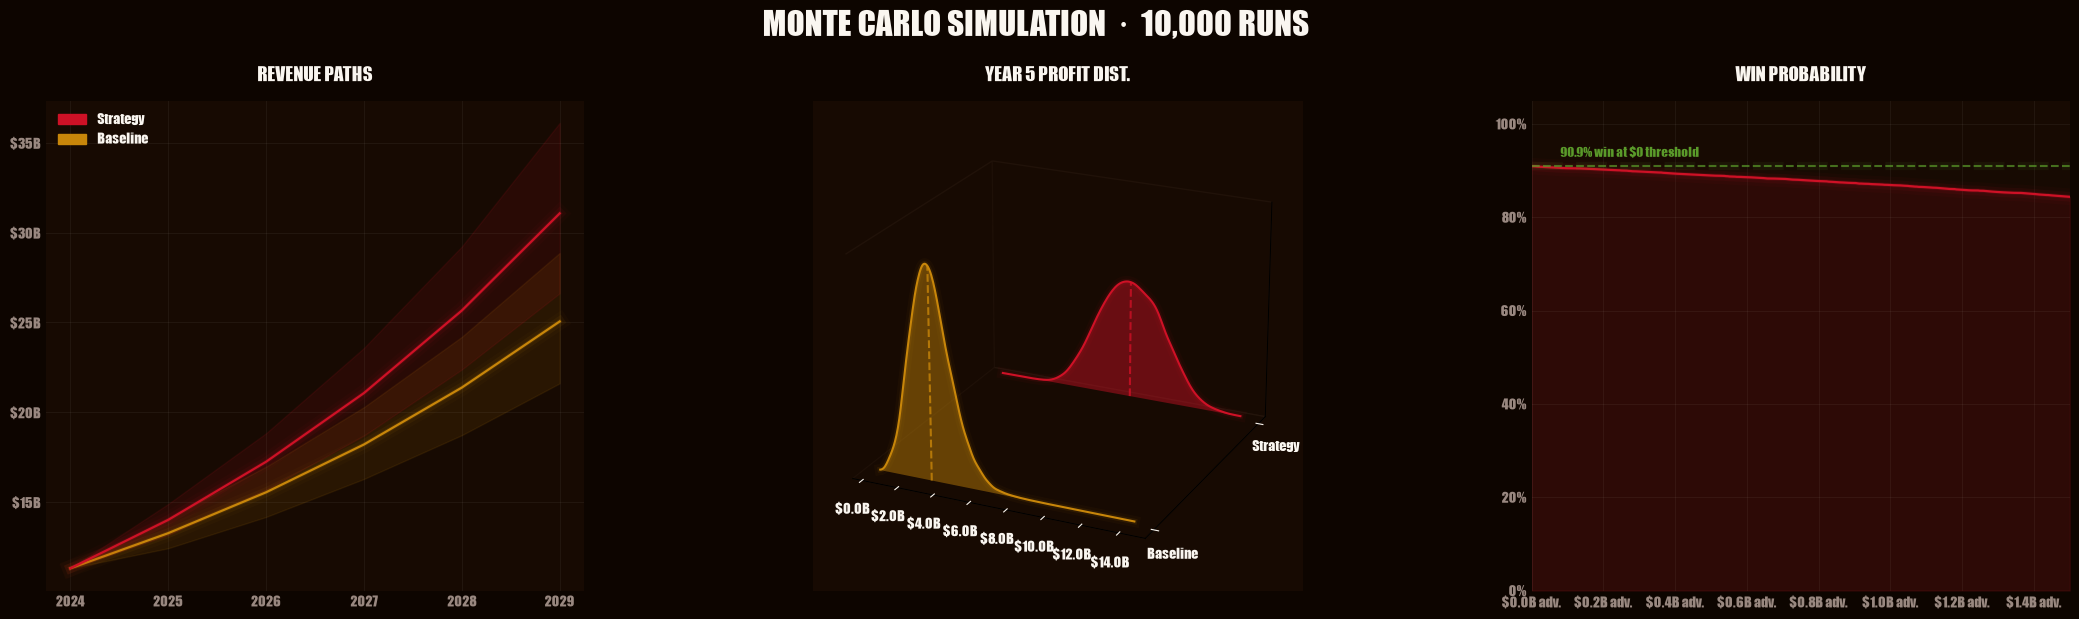

✓ Saved to Downloads.


In [62]:
# ═══════════════════════════════════════════════
# CELL A — MONTE CARLO GRAPHS
# ═══════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.stats import gaussian_kde

BG    = '#0D0500'
PANEL = '#170A02'
RED   = '#CE1126'
GOLD  = '#C8860A'
GREEN = '#5A9A2A'
CREAM = '#FAF6F0'

plt.rcParams.update({
    'font.family':        'Impact',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'axes.grid':          True,
    'grid.alpha':         0.05,
    'grid.color':         CREAM,
    'figure.facecolor':   BG,
    'axes.facecolor':     PANEL,
    'text.color':         CREAM,
    'xtick.color':        '#998880',
    'ytick.color':        '#998880',
})

def glow2d(ax, x, y, color, fill=False):
    for w, a in [(12, 0.03), (7, 0.07), (3, 0.15), (1.6, 1.0)]:
        ax.plot(x, y, color=color, lw=w, alpha=a)
    if fill:
        ax.fill_between(x, y, alpha=0.07, color=color)

def glow3d(ax, x, y_val, z, color):
    for w, a in [(8, 0.04), (4, 0.10), (1.5, 1.0)]:
        ax.plot(x, [y_val]*len(x), z, color=color, lw=w, alpha=a)

strat_rev = results['base'][0]
strat_op  = results['base'][1]

fig = plt.figure(figsize=(22, 7), facecolor=BG)
fig.subplots_adjust(left=0.05, right=0.97, top=0.84, bottom=0.14, wspace=0.38)
fig.suptitle('MONTE CARLO SIMULATION  ·  10,000 RUNS', fontsize=24,
             fontweight='bold', color=CREAM, y=0.97)

ax1 = fig.add_subplot(1, 3, 1)
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax3 = fig.add_subplot(1, 3, 3)
axes = [ax1, ax2, ax3]

yr    = range(6)
xlbls = ['2024', '2025', '2026', '2027', '2028', '2029']

# ── 1. Revenue Growth Paths ──────────────────────────────────
ax = axes[0]
b_med = np.concatenate([[11.314], np.median(base_rev, axis=0)/1000])
s_med = np.concatenate([[11.314], np.median(strat_rev, axis=0)/1000])
b_p10 = np.concatenate([[11.314], np.percentile(base_rev, 10, axis=0)/1000])
b_p90 = np.concatenate([[11.314], np.percentile(base_rev, 90, axis=0)/1000])
s_p10 = np.concatenate([[11.314], np.percentile(strat_rev, 10, axis=0)/1000])
s_p90 = np.concatenate([[11.314], np.percentile(strat_rev, 90, axis=0)/1000])

ax.fill_between(yr, b_p10, b_p90, alpha=0.10, color=GOLD)
ax.fill_between(yr, s_p10, s_p90, alpha=0.10, color=RED)
glow2d(ax, yr, b_med, GOLD)
glow2d(ax, yr, s_med, RED)

ax.set_xticks(range(6))
ax.set_xticklabels(xlbls, fontsize=10)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.0f}B'))
ax.set_title('REVENUE PATHS', fontsize=14, color=CREAM, pad=14)
ax.tick_params(length=0)
ax.legend(handles=[mpatches.Patch(color=RED,  label='Strategy'),
                   mpatches.Patch(color=GOLD, label='Baseline')],
          frameon=False, fontsize=10, labelcolor=CREAM)

# ── 2. Year 5 Profit Distribution (3D Ridge) ─────────────────
ax = axes[1]

b_y5    = base_op[:, 4] / 1000
s_y5    = strat_op[:, 4] / 1000
x_range = np.linspace(min(b_y5.min(), s_y5.min()) - 0.3,
                      max(b_y5.max(), s_y5.max()) + 0.3, 300)

kde_b = gaussian_kde(b_y5, bw_method=0.18)
kde_s = gaussian_kde(s_y5, bw_method=0.18)
z_b   = kde_b(x_range)
z_s   = kde_s(x_range)

# Baseline ridge at y=0
verts_b = ([(x_range[0], 0, 0)]
           + [(x, 0, z) for x, z in zip(x_range, z_b)]
           + [(x_range[-1], 0, 0)])
poly_b = Poly3DCollection([verts_b])
poly_b.set_facecolor(GOLD)
poly_b.set_alpha(0.45)
poly_b.set_edgecolor('none')
ax.add_collection3d(poly_b)
glow3d(ax, x_range, 0, z_b, GOLD)

# Strategy ridge at y=1
verts_s = ([(x_range[0], 1, 0)]
           + [(x, 1, z) for x, z in zip(x_range, z_s)]
           + [(x_range[-1], 1, 0)])
poly_s = Poly3DCollection([verts_s])
poly_s.set_facecolor(RED)
poly_s.set_alpha(0.45)
poly_s.set_edgecolor('none')
ax.add_collection3d(poly_s)
glow3d(ax, x_range, 1, z_s, RED)

# Median markers
for val, col, y_pos in [(np.median(b_y5), GOLD, 0), (np.median(s_y5), RED, 1)]:
    ax.plot([val, val], [y_pos, y_pos], [0, kde_b(val)[0] if col==GOLD else kde_s(val)[0]],
            color=col, lw=1.5, alpha=0.8, linestyle='--')

ax.set_yticks([0, 1])
ax.set_yticklabels(['Baseline', 'Strategy'], color=CREAM, fontsize=10)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.1f}B'))
ax.set_title('YEAR 5 PROFIT DIST.', fontsize=14, color=CREAM, pad=14)
ax.view_init(elev=22, azim=-65)
ax.set_facecolor(PANEL)
ax.xaxis.pane.set_facecolor(PANEL)
ax.yaxis.pane.set_facecolor(PANEL)
ax.zaxis.pane.set_facecolor(PANEL)
ax.xaxis.pane.set_edgecolor('#2A1A10')
ax.yaxis.pane.set_edgecolor('#2A1A10')
ax.zaxis.pane.set_edgecolor('#2A1A10')
ax.tick_params(colors=CREAM, length=0)
ax.set_zticks([])
ax.grid(False)

# ── 3. Win Probability Curve ─────────────────────────────────
ax = axes[2]
thresholds = np.linspace(0, 1.5, 300)
win_probs  = [(strat_rev[:, 4] - base_rev[:, 4] > t * 1000).mean()
              for t in thresholds]

ax.fill_between(thresholds, win_probs, alpha=0.12, color=RED)
glow2d(ax, thresholds, win_probs, RED)

win_0 = (strat_rev[:, 4] > base_rev[:, 4]).mean()
for lw, a in [(6, 0.08), (1.5, 0.7)]:
    ax.axhline(win_0, color=GREEN, lw=lw, alpha=a, linestyle='--')
ax.text(0.08, win_0 + 0.02, f'{win_0*100:.1f}% win at $0 threshold',
        color=GREEN, fontsize=9)

ax.set_xlim(0, 1.5)
ax.set_ylim(0, 1.05)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:.1f}B adv.'))
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v*100:.0f}%'))
ax.set_title('WIN PROBABILITY', fontsize=14, color=CREAM, pad=14)
ax.tick_params(length=0)

plt.savefig('/Users/vrundgurjar/Downloads/monte_carlo_graphs.png',
            dpi=180, bbox_inches='tight', facecolor=BG)
plt.show()
print("✓ Saved to Downloads.")

In [63]:
print(f"Baseline Y5 FCF median:  ${np.median(base_fcf[:, 4])/1000:.2f}B")
print(f"Strategy Y5 FCF median:  ${np.median(strat_fcf[:, 4])/1000:.2f}B")
print(f"Baseline P50 price:      ${np.median(prices_baseline_fixed):.2f}")
print(f"Strategy P50 price:      ${np.median(prices_strategy):.2f}")

Baseline Y5 FCF median:  $1.72B
Strategy Y5 FCF median:  $4.07B
Baseline P50 price:      $36.00
Strategy P50 price:      $46.82
